# Assessment Task 2 – Practical **Assessment**

# Importing libraries and data

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap -q

In [2]:
import pickle
import os
import shap
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler as SS
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
# Settings for display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_csv('/content/adverts 1 (1).csv') # Dear Sir or Ma'am, The dataset was uploaded to Colab's runtime, please update this path according to where you are uploading during evaluation
print(f"Loaded Dataset...")

Loaded Dataset...


/tmp/ipykernel_50854/1504929378.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/adverts 1 (1).csv') # Dear Sir or Ma'am, The dataset was uploaded to Colab's runtime, please update this path according to where you are uploading during evaluation


# **1. Data | Domain Understanding and Exploration**

# Basic EDA

In [4]:
print("Shape~")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print("\nColumns & Data Types~")
print("=" * 50)
print(df.dtypes)
print("\nHead~")
df.head()

Shape~
Rows: 155,394  |  Columns: 12

Columns & Data Types~
public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                    float64
body_type                 object
crossover_car_and_van     object
fuel_type                 object
dtype: object

Head~


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.00,NaN,Grey,Volvo,XC90,NEW,NaN,73970.00,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.00,61,Blue,Jaguar,XF,USED,2011.00,7000.00,Saloon,False,Diesel
2,202007020778474,7800.00,17,Grey,SKODA,Yeti,USED,2017.00,14000.00,SUV,False,Petrol
3,202007080986776,45000.00,16,Brown,Vauxhall,Mokka,USED,2016.00,7995.00,Hatchback,False,Diesel
4,202007161321269,64000.00,64,Grey,Land Rover,Range Rover Sport,USED,2015.00,26995.00,SUV,False,Diesel


In [5]:
# Checking for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    '%': missing_pct
}).sort_values('%', ascending=False)

print(missing_df[missing_df['Missing Values'] > 0])

                       Missing Values    %
year_of_registration            12760 8.21
reg_code                        12196 7.85
standard_colour                  2052 1.32
body_type                         311 0.20
fuel_type                         229 0.15
mileage                            44 0.03
standard_make                       1 0.00
vehicle_condition                   1 0.00
standard_model                      1 0.00
price                               1 0.00
crossover_car_and_van               1 0.00


In [6]:
df.describe()

,public_reference,mileage,year_of_registration,price
count,155394.00,155350.00,142634.00,155393.00
mean,202007134352801.09,37804.48,2015.01,17267.94
std,16623459095.21,34978.28,6.97,44216.80
min,201309178833714.00,0.00,1007.00,180.00
25%,202009023204494.25,10496.00,2013.00,7495.00
50%,202009304401157.00,28680.00,2016.00,12597.00
75%,202010175122602.75,57000.00,2018.00,20000.00
max,202011015683299.00,999999.00,2020.00,9999999.00


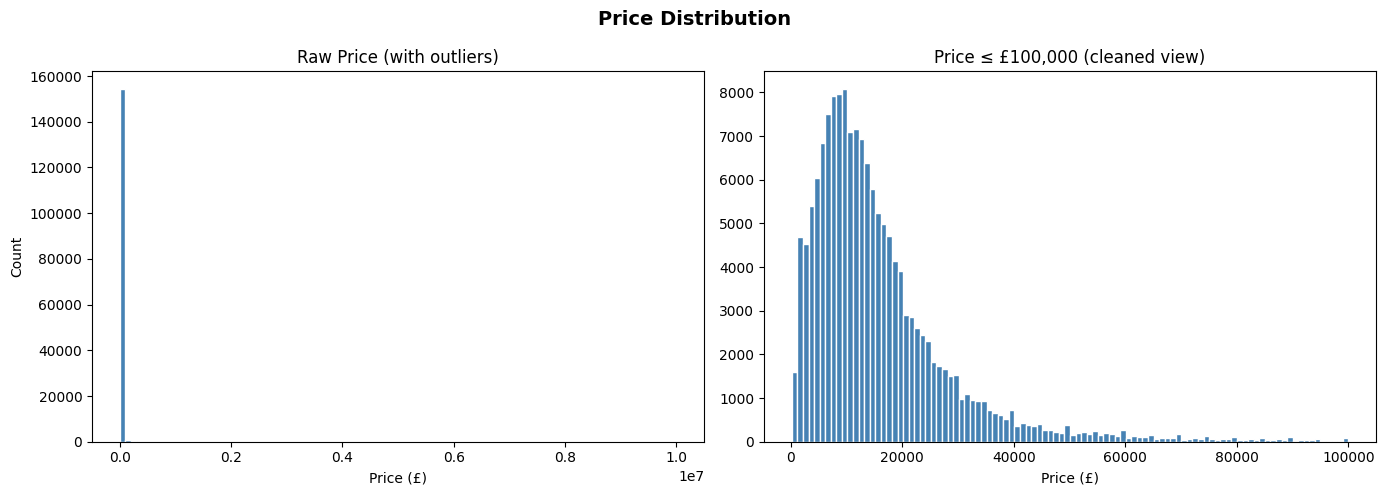

->Prices above £100,000: 1,057


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Price (with outliers)')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Count')

#capped at £100k for better readability
axes[1].hist(df[df['price'] <= 100000]['price'], bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Price ≤ £100,000 (cleaned view)')
axes[1].set_xlabel('Price (£)')
plt.tight_layout()
plt.show()

print(f"->Prices above £100,000: {(df['price'] > 100000).sum():,}")

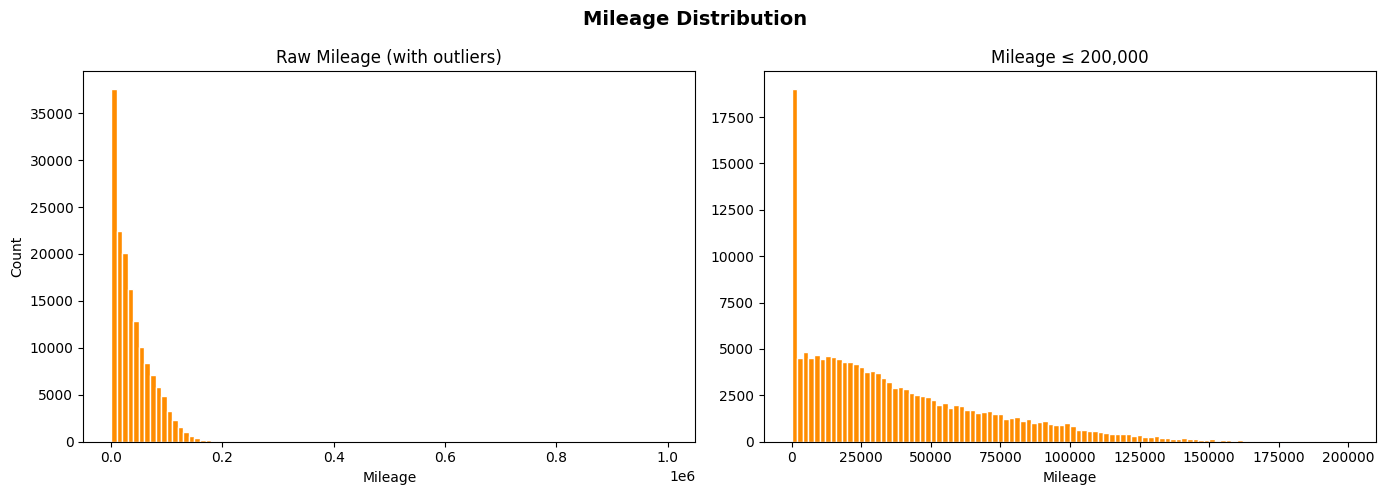

->Mileage above 200,000: 127
->Mileage = 999,999: 1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mileage Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['mileage'], bins=100, color='darkorange', edgecolor='white')
axes[0].set_title('Raw Mileage (with outliers)')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Count')
# cap at 200,000 for better readability
axes[1].hist(df[df['mileage'] <= 200000]['mileage'], bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('Mileage ≤ 200,000')
axes[1].set_xlabel('Mileage')
plt.tight_layout()
plt.show()

print(f"->Mileage above 200,000: {(df['mileage'] > 200000).sum():,}")
print(f"->Mileage = 999,999: {(df['mileage'] == 999999).sum():,}")

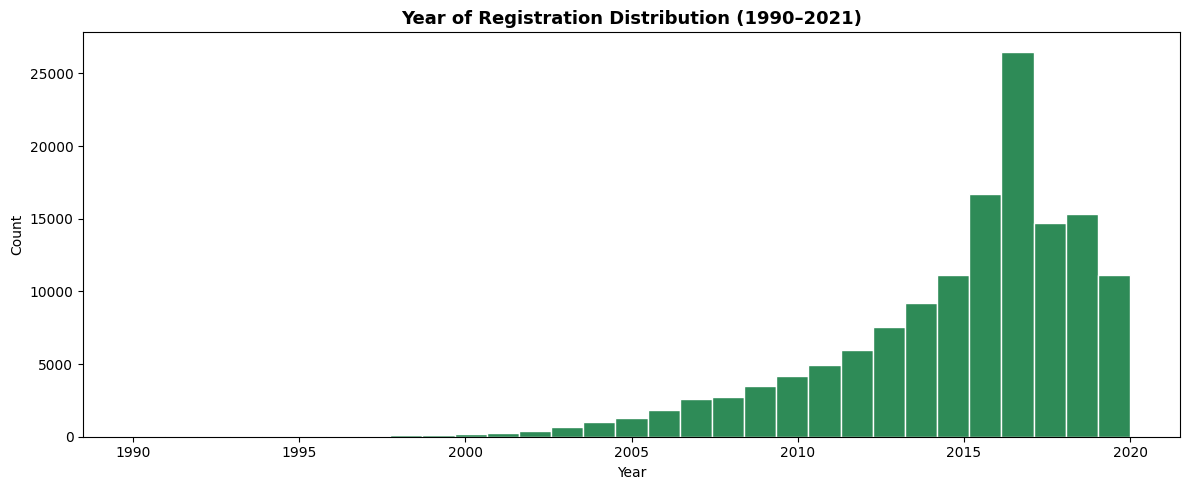

->Registrations before 1990: 276
->Registrations of year 999: 0


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

valid_years = df[(df['year_of_registration'] >= 1990) &
                 (df['year_of_registration'] <= 2021)]['year_of_registration']

ax.hist(valid_years, bins=31, color='seagreen', edgecolor='white')
ax.set_title('Year of Registration Distribution (1990–2021)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"->Registrations before 1990: {(df['year_of_registration'] < 1990).sum():,}")
print(f"->Registrations of year 999: {(df['year_of_registration'] == 999).sum():,}")

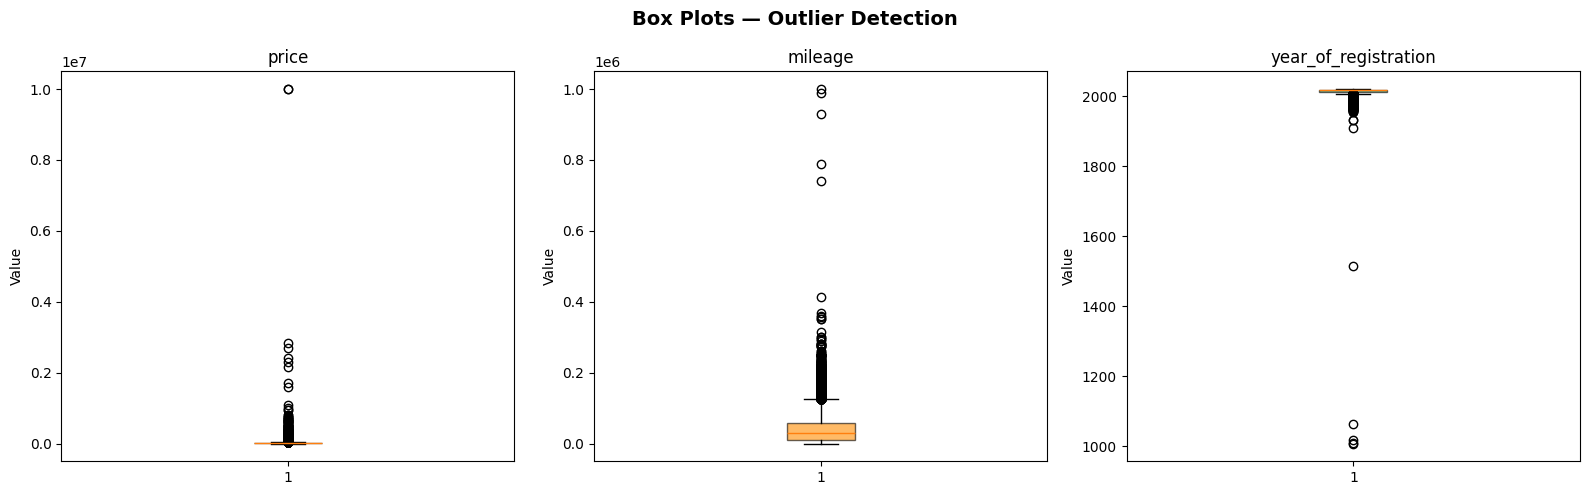

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['price', 'mileage', 'year_of_registration'],
                                  ['steelblue', 'darkorange', 'seagreen']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

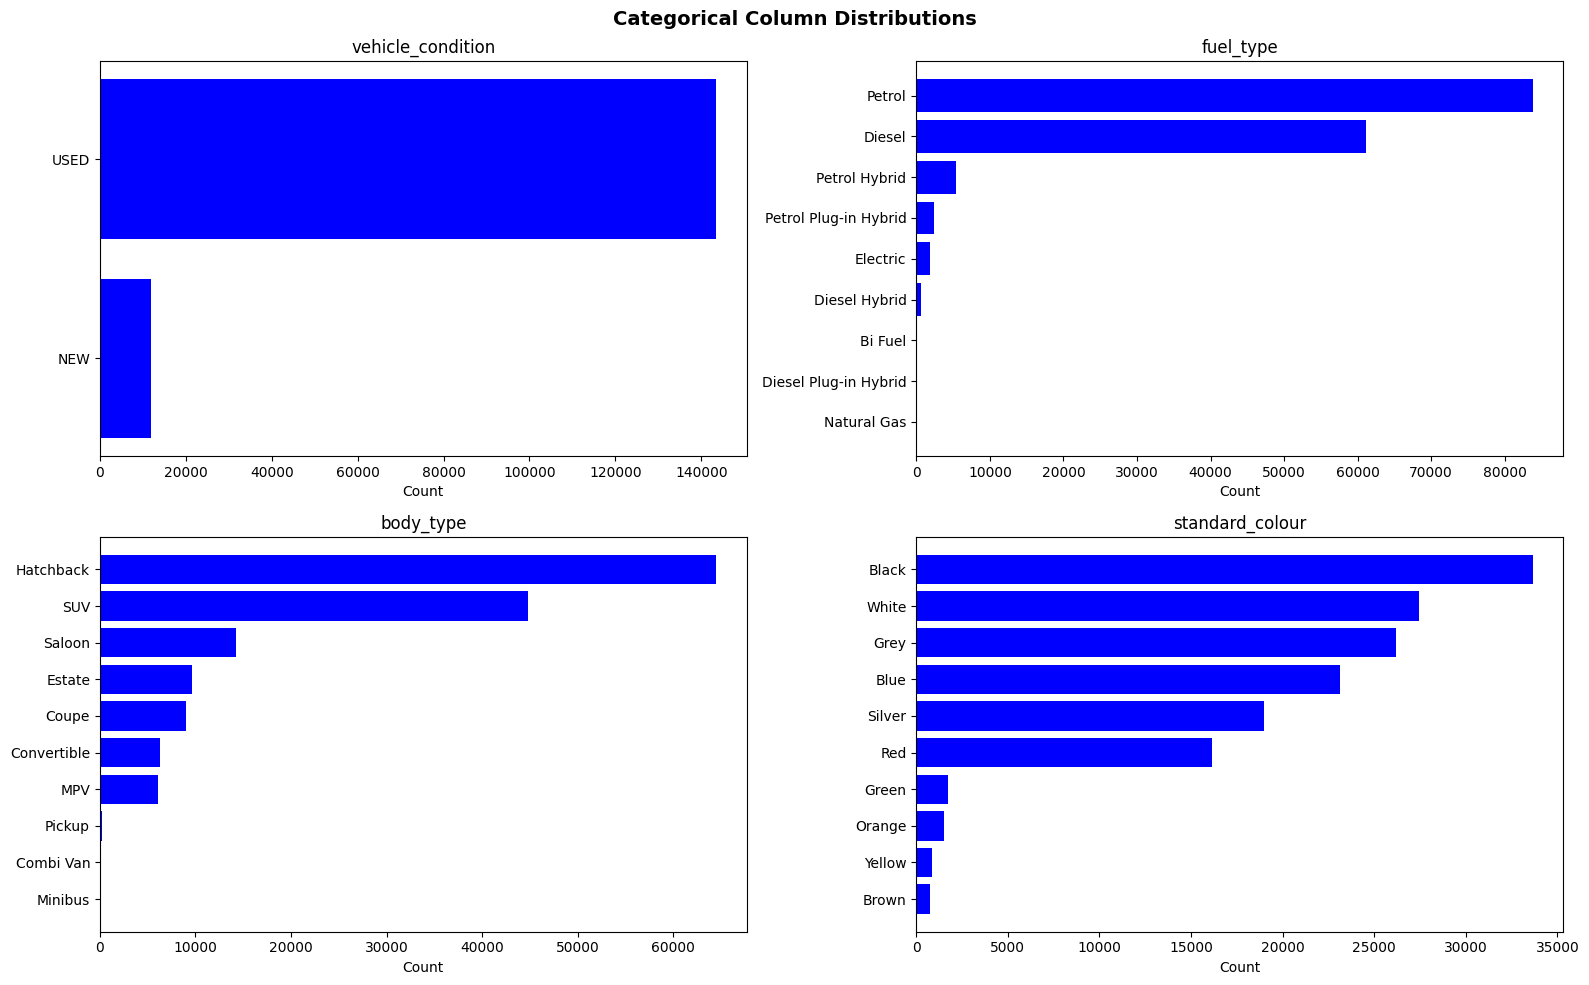

In [11]:
cat_cols = ['vehicle_condition', 'fuel_type', 'body_type', 'standard_colour']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Categorical Column Distributions', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts().head(10)
    ax.barh(counts.index[::-1], counts.values[::-1], color='blue')
    ax.set_title(col)
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

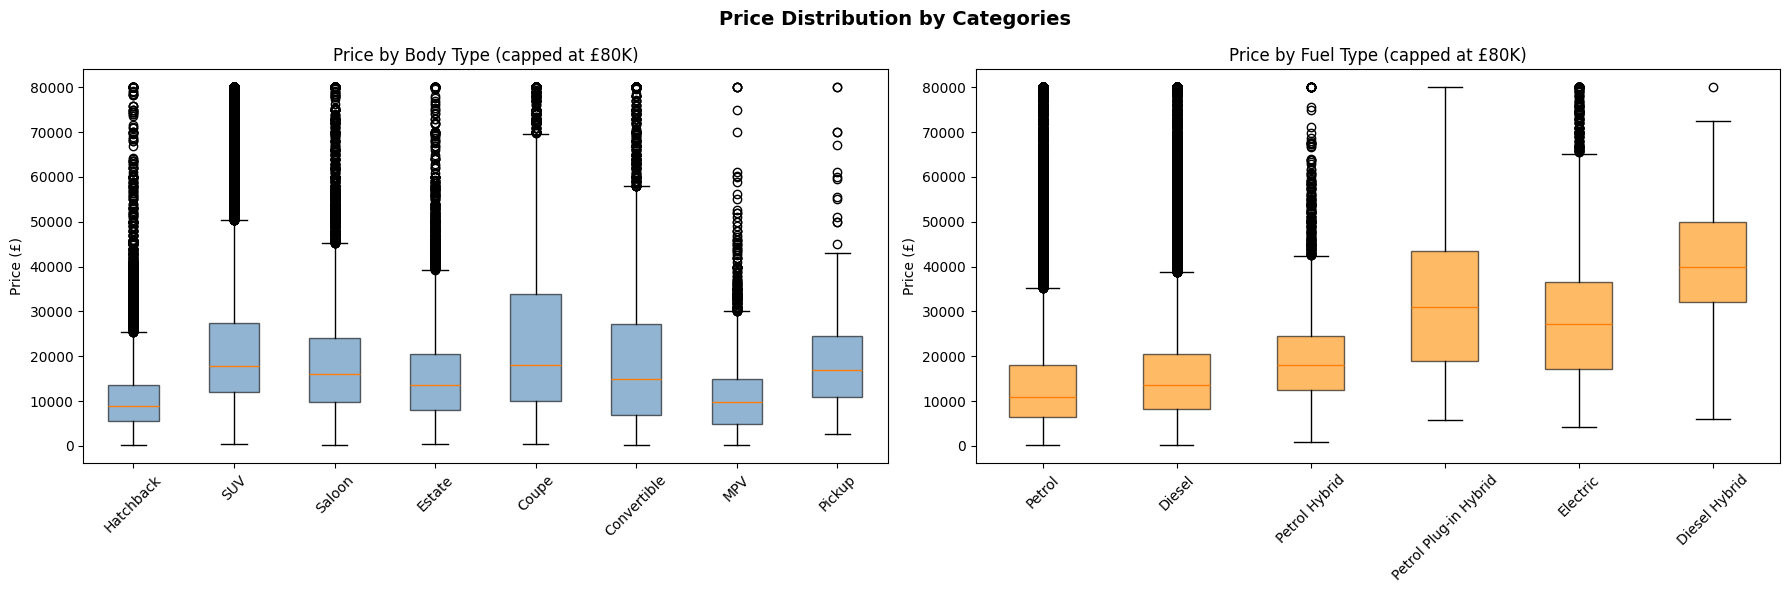

Insights:
  Hatchback            median: £8,995
  SUV                  median: £17,899
  Saloon               median: £16,000
  Estate               median: £13,490
  Coupe                median: £17,990
  Convertible          median: £14,948
  MPV                  median: £9,850
  Pickup               median: £17,000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Price Distribution by Categories', fontsize=14, fontweight='bold')

# Price by body_type
top_bodies = df['body_type'].value_counts().head(8).index
body_data = [df[df['body_type'] == bt]['price'].clip(0, 80000) for bt in top_bodies]
bp1 = axes[0].boxplot(body_data, tick_labels=top_bodies, patch_artist=True, vert=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[0].set_title('Price by Body Type (capped at £80K)')
axes[0].set_ylabel('Price (£)')
axes[0].tick_params(axis='x', rotation=45)

# Price by fuel_type
top_fuels = df['fuel_type'].value_counts().head(6).index
fuel_data = [df[df['fuel_type'] == ft]['price'].clip(0, 80000) for ft in top_fuels]
bp2 = axes[1].boxplot(fuel_data, tick_labels=top_fuels, patch_artist=True, vert=True)
for patch in bp2['boxes']:
    patch.set_facecolor('darkorange')
    patch.set_alpha(0.6)
axes[1].set_title('Price by Fuel Type (capped at £80K)')
axes[1].set_ylabel('Price (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Insights
print("Insights:")
for bt in top_bodies:
    m = df[df['body_type'] == bt]['price'].median()
    print(f"  {bt:<20} median: £{m:,.0f}")

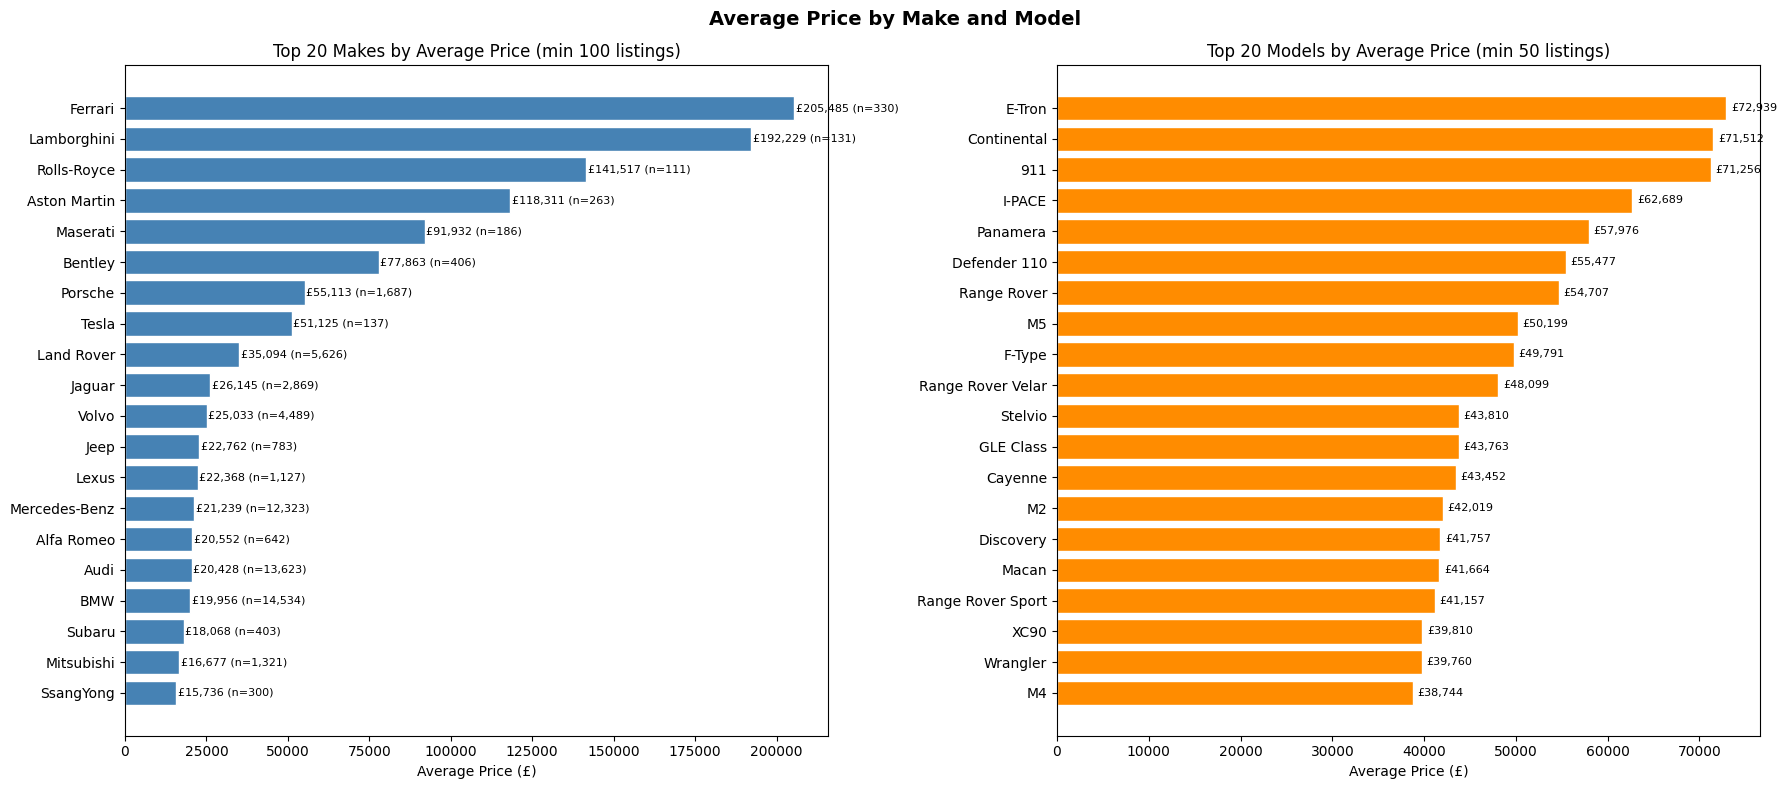


Price range by top 10 volume makes:
  BMW                  median: £  16,810  range: £   500 – £   199,995  (n=14,534)
  Audi                 median: £  16,499  range: £   350 – £   152,995  (n=13,623)
  Volkswagen           median: £  12,682  range: £   250 – £    74,999  (n=13,136)
  Vauxhall             median: £   7,690  range: £   250 – £    46,650  (n=12,962)
  Mercedes-Benz        median: £  18,100  range: £   499 – £   325,000  (n=12,323)
  Nissan               median: £  10,490  range: £   295 – £   169,000  (n=7,726)
  Toyota               median: £   9,850  range: £   495 – £   232,504  (n=6,805)
  Peugeot              median: £   8,290  range: £   295 – £    40,993  (n=5,936)
  Land Rover           median: £  29,613  range: £   595 – £   265,000  (n=5,626)
  Renault              median: £   9,690  range: £   200 – £    63,500  (n=5,023)


In [13]:
# The car's make and amodel can tell alot about the price, important metric for FE
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Average Price by Make and Model', fontsize=14, fontweight='bold')

# Top 20 makes by average price
make_prices = df.groupby('standard_make')['price'].agg(['mean', 'count'])
make_prices = make_prices[make_prices['count'] >= 100].sort_values('mean', ascending=True)
top20_makes = make_prices.tail(20)

axes[0].barh(top20_makes.index, top20_makes['mean'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Makes by Average Price (min 100 listings)')
axes[0].set_xlabel('Average Price (£)')
for i, (_, row) in enumerate(top20_makes.iterrows()):
    axes[0].text(row['mean'] + 500, i, f"£{row['mean']:,.0f} (n={row['count']:,.0f})",
                 va='center', fontsize=8)

# Top 20 models by average price
model_prices = df.groupby('standard_model')['price'].agg(['mean', 'count'])
model_prices = model_prices[model_prices['count'] >= 100].sort_values('mean', ascending=True)
top20_models = model_prices.tail(20)

axes[1].barh(top20_models.index, top20_models['mean'], color='darkorange', edgecolor='white')
axes[1].set_title('Top 20 Models by Average Price (min 50 listings)')
axes[1].set_xlabel('Average Price (£)')
for i, (_, row) in enumerate(top20_models.iterrows()):
    axes[1].text(row['mean'] + 500, i, f"£{row['mean']:,.0f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Price range by makeshow why make/model dominates predictions
print("\nPrice range by top 10 volume makes:")
top10_vol = df['standard_make'].value_counts().head(10).index
for make in top10_vol:
    prices = df[df['standard_make'] == make]['price']
    print(f"  {make:<20} median: £{prices.median():>8,.0f}  "
          f"range: £{prices.min():>6,.0f} – £{prices.max():>10,.0f}  "
          f"(n={len(prices):,})")

# Investigation of missing values

In [14]:
# Cross-tabulate missing year against vehicle_condition
missing_year = df['year_of_registration'].isnull()

cross = pd.crosstab(
    df['vehicle_condition'],
    missing_year,
    margins=True
)
cross.columns = ['Year Present', 'Year Missing', 'Total']
print("\nCross-tab: vehicle_condition vs missing year_of_registration\n")
print(cross)

# Calculate % of NEW cars that are missing year
new_cars = df[df['vehicle_condition'] == 'NEW']
new_missing_pct = new_cars['year_of_registration'].isnull().mean() * 100

used_cars = df[df['vehicle_condition'] == 'USED']
used_missing_pct = used_cars['year_of_registration'].isnull().mean() * 100

print(f"\n-> % of NEW cars missing year_of_registration:  {new_missing_pct:.1f}%")
print(f"-> % of USED cars missing year_of_registration: {used_missing_pct:.1f}%")


Cross-tab: vehicle_condition vs missing year_of_registration

                   Year Present  Year Missing   Total
vehicle_condition                                    
NEW                           0         11963   11963
USED                     142634           796  143430
All                      142634         12759  155393

-> % of NEW cars missing year_of_registration:  100.0%
-> % of USED cars missing year_of_registration: 0.6%


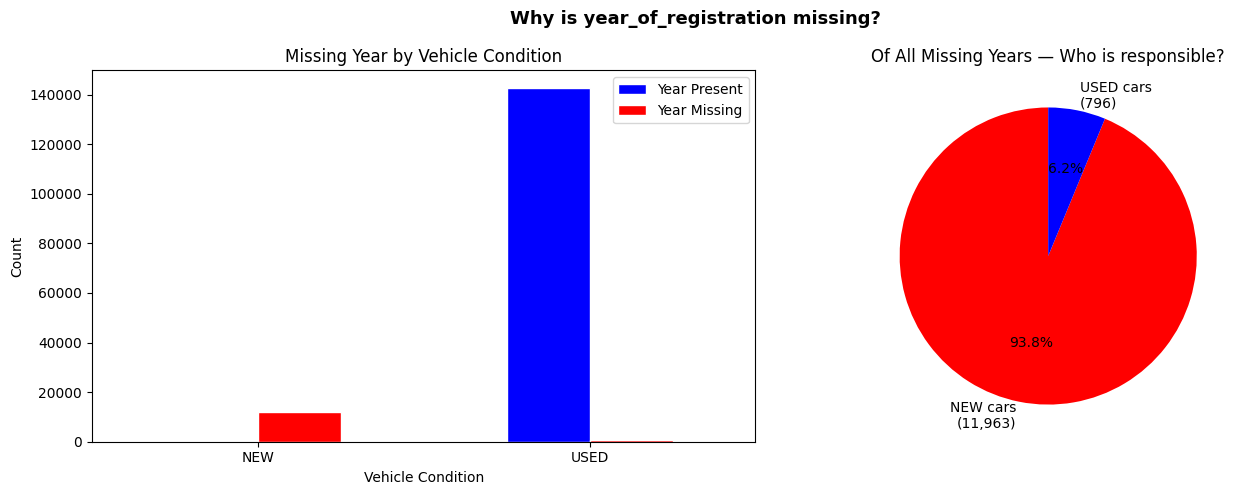

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Why is year_of_registration missing?',
             fontsize=13, fontweight='bold')
condition_missing =   df.groupby('vehicle_condition')['year_of_registration'].apply(
    lambda x: pd.Series({
        'Present': x.notna().sum(),
        'Missing': x.isna().sum()
    })
).unstack()

condition_missing.plot(kind='bar', ax=axes[0], color=['blue', 'red'],
                       edgecolor='white', width=0.5)
axes[0].set_title('Missing Year by Vehicle Condition')
axes[0].set_xlabel('Vehicle Condition')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Year Present', 'Year Missing'])

new_missing =      new_cars['year_of_registration'].isnull().sum()
used_missing = used_cars['year_of_registration'].isnull().sum()

axes[1].pie(
    [new_missing, used_missing],
    labels=[f'NEW cars\n({new_missing:,})', f'USED cars\n({used_missing:,})'],
    colors=['red', 'blue'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Of All Missing Years — Who is responsible?')
plt.tight_layout()
plt.show()

In [16]:
# Checking for missing reg codes
print("Missing reg_code by vehicle_condition:")
print(df.groupby('vehicle_condition')['reg_code'].apply(
    lambda x: f"               Missing: {x.isna().sum():,} / {len(x):,} ({x.isna().mean()*100:.1f}%)"
))

Missing reg_code by vehicle_condition:
vehicle_condition
NEW                    Missing: 11,963 / 11,963 (100.0%)
USED                       Missing: 232 / 143,430 (0.2%)
Name: reg_code, dtype: object


In [17]:
#Missing mileage Rows

missing_mileage = df[df['mileage'].isna()].copy()
print(f"Total rows with missing mileage: {len(missing_mileage)}")

print(f"\nBreakdown by vehicle_condition:")
print(missing_mileage['vehicle_condition'].value_counts())

print(f"\nBreakdown by body_type:")
print(missing_mileage['body_type'].value_counts().head(10))

print(f"\nPrice stats for missing mileage rows:")
print(missing_mileage['price'].describe())

# Decision
is_new_pct = (missing_mileage['vehicle_condition'] == 'NEW').mean() * 100
print(f"\nDecision:")
print(f"  {is_new_pct:.0f}% of missing mileage rows are NEW cars")
if is_new_pct > 50:
    print(f"  NEW cars naturally have 0 mileage so will be imputed with 0 in cleaning")
    print(f"  Remaining USED cars with missing mileage so will be dropped since they are two few to impute accurately")
else:
    print(f"  Mixed condition — rows will be dropped in cleaning phase")

Total rows with missing mileage: 44

Breakdown by vehicle_condition:
vehicle_condition
USED    43
Name: count, dtype: int64

Breakdown by body_type:
body_type
Hatchback      16
SUV            15
Convertible     4
Estate          4
Saloon          3
Coupe           1
Name: count, dtype: int64

Price stats for missing mileage rows:
count       43.00
mean     21213.02
std      28079.80
min        750.00
25%       7970.00
50%      13495.00
75%      23747.00
max     174995.00
Name: price, dtype: float64

Decision:
  0% of missing mileage rows are NEW cars
  Mixed condition — rows will be dropped in cleaning phase


# Logical Checks

I came up with certain logical conditions that made sense and should hold true

In [18]:
# Check 1: Zero mileage but USED
check1 = df[(df['mileage'] == 0) & (df['vehicle_condition'] == 'USED')]
print(f"\n Check 1 — Zero mileage but listed as USED: {len(check1):,} rows")

# Check 2: NEW cars with mileage > 100
check2 = df[(df['vehicle_condition'] == 'NEW') & (df['mileage'] > 100)]
print(f" Check 2 — NEW cars with mileage > 100:    {len(check2):,} rows")

# Check 3: Year of registration after 2020
check3 = df[df['year_of_registration'] > 2020]
print(f" Check 3 — Registration year after 2020:   {len(check3):,} rows")

# Check 4: Year of registration before 1980
check4 = df[df['year_of_registration'] < 1980]
print(f" Check 4 — Registration year before 1980:  {len(check4):,} rows")

#Check 5: Price under £100
check5 = df[df['price'] < 100]
print(f" Check 5 — Price under £100:               {len(check5):,} rows")

# Check 6: USED cars missing reg_code
check6 = df[(df['vehicle_condition'] == 'USED') & (df['reg_code'].isnull())]
print(f" Check 6 — USED cars with no reg_code:     {len(check6):,} rows")

# Check 7: Old car (pre-2005) with zero mileage
check7 = df[(df['year_of_registration'] < 2005) & (df['mileage'] == 0)]
print(f" Check 7 — Pre-2005 car with 0 mileage:    {len(check7):,} rows")

# Check 8: NEW car that somehow has a year_of_registration
check8 = df[(df['vehicle_condition'] == 'NEW') & (df['year_of_registration'].notna())]
print(f" Check 8 — NEW cars WITH a reg year:       {len(check8):,} rows")


 Check 1 — Zero mileage but listed as USED: 153 rows
 Check 2 — NEW cars with mileage > 100:    0 rows
 Check 3 — Registration year after 2020:   0 rows
 Check 4 — Registration year before 1980:  127 rows
 Check 5 — Price under £100:               0 rows
 Check 6 — USED cars with no reg_code:     232 rows
 Check 7 — Pre-2005 car with 0 mileage:    4 rows
 Check 8 — NEW cars WITH a reg year:       0 rows


In [19]:
# Check 1 detail
print("\n~Check 1: Zero mileage USED cars")
print(check1[['standard_make', 'standard_model', 'vehicle_condition',
               'mileage', 'year_of_registration', 'price']].head(10))
print(f"  Median price of these: £{check1['price'].median():,.0f}")

# Check 4 detail
print("\n~Check 4: Registration year before 1980")
print(check4[['standard_make', 'standard_model', 'vehicle_condition',
               'mileage', 'price']].head(10))

# Check 6 detail
print("\n~Check 6: USED cars with no reg_code")
print(check6[['standard_make', 'standard_model', 'vehicle_condition',
               'mileage', 'year_of_registration', 'price']].head(10))

# Check 7 detail
print("\n~Check 7: Pre-2005 car with 0 mileage")
print(check7[['standard_make', 'standard_model', 'year_of_registration',
               'mileage', 'vehicle_condition', 'price']].head(10))


~Check 1: Zero mileage USED cars
       standard_make     standard_model vehicle_condition  mileage  \
810       Land Rover  Range Rover Velar              USED     0.00   
1656        Vauxhall           Insignia              USED     0.00   
1855   Mercedes-Benz          CLA Class              USED     0.00   
2201      Land Rover        Range Rover              USED     0.00   
2754            Audi                 A1              USED     0.00   
3541      Volkswagen               Golf              USED     0.00   
5712         Renault               Clio              USED     0.00   
8650            Fiat               500X              USED     0.00   
8677         Porsche                911              USED     0.00   
10435     Volkswagen               Polo              USED     0.00   

       year_of_registration    price  
810                 2020.00 52995.00  
1656                2013.00  2975.00  
1855                2020.00 34995.00  
2201                2020.00 82750.00  


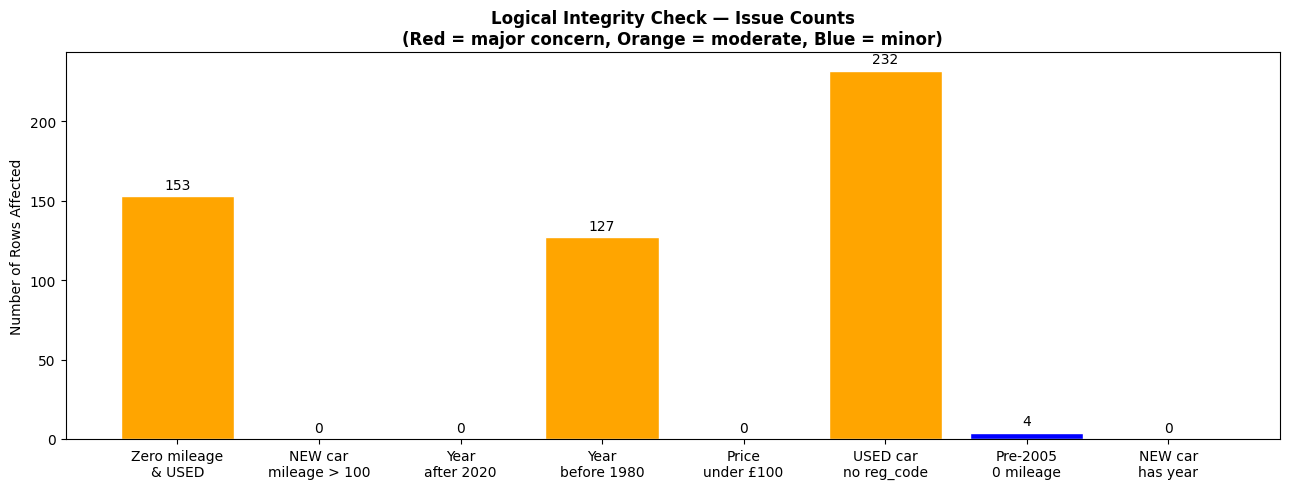

In [20]:
checks = {
    'Zero mileage\n& USED': len(check1),
    'NEW car\nmileage > 100': len(check2),
    'Year\nafter 2020': len(check3),
    'Year\nbefore 1980': len(check4),
    'Price\nunder £100': len(check5),
    'USED car\nno reg_code': len(check6),
    'Pre-2005\n0 mileage': len(check7),
    'NEW car\nhas year': len(check8),
}

plt.figure(figsize=(13, 5))
colors = ['red' if v > 500 else 'orange' if v > 50 else 'blue'
          for v in checks.values()]
bars = plt.bar(checks.keys(), checks.values(), color=colors, edgecolor='white')
plt.bar_label(bars, fmt='%d', padding=3, fontsize=10)
plt.title('Logical Integrity Check — Issue Counts\n(Red = major concern, Orange = moderate, Blue = minor)',
          fontsize=12, fontweight='bold')
plt.ylabel('Number of Rows Affected')
plt.tight_layout()
plt.show()

In [21]:
zero_used = df[(df['mileage'] == 0) & (df['vehicle_condition'] == 'USED')].copy()

print("Zero mileage USED cars — breakdown by year of registration:")
print(zero_used['year_of_registration'].value_counts().sort_index())

print(f"\nTotal: {len(zero_used)}")
print(f"Registered 2018 or later: {(zero_used['year_of_registration'] >= 2018).sum()}")
print(f"Registered before 2018:   {(zero_used['year_of_registration'] < 2018).sum()}")
print(f"Missing year entirely:    {zero_used['year_of_registration'].isna().sum()}")

Zero mileage USED cars — breakdown by year of registration:
year_of_registration
1981.00      1
1986.00      1
1987.00      1
1999.00      1
2006.00      1
2007.00      1
2011.00      1
2013.00      2
2015.00      2
2016.00      2
2018.00      2
2019.00      4
2020.00    127
Name: count, dtype: int64

Total: 153
Registered 2018 or later: 133
Registered before 2018:   13
Missing year entirely:    7


In [22]:
# Group A: Recent cars with 0 mileage
group_a = zero_used[zero_used['year_of_registration'] >= 2018]

# Group B: Old/classic cars with 0 mileage — untrustworthy mileage
group_b = zero_used[zero_used['year_of_registration'] < 2018]

# Group C: No year at all
group_c = zero_used[zero_used['year_of_registration'].isna()]

print(f"Group A ~ Recent cars, 0 miles, USED: {len(group_a)} rows")
print(f"  Median price: £{group_a['price'].median():,.0f}")
print(f"  Makes: {group_a['standard_make'].value_counts().head(5).to_dict()}")

print(f"\nGroup B ~ Older car, 0 miles, USED: {len(group_b)} rows")
print(f"  These are most likely wrong since old cars rarely have 0 miles")
print(f"  Median price: £{group_b['price'].median():,.0f}")
print(f"  Makes: {group_b['standard_make'].value_counts().head(5).to_dict()}")

print(f"\nGroup C ~ No year, 0 miles, USED: {len(group_c)} rows")
print(f"  Median price: £{group_c['price'].median():,.0f}")

Group A ~ Recent cars, 0 miles, USED: 133 rows
  Median price: £25,000
  Makes: {'Volkswagen': 39, 'Mercedes-Benz': 19, 'Audi': 17, 'SKODA': 8, 'Honda': 6}

Group B ~ Older car, 0 miles, USED: 13 rows
  These are most likely wrong since old cars rarely have 0 miles
  Median price: £9,495
  Makes: {'Land Rover': 2, 'Porsche': 2, 'Volkswagen': 2, 'Vauxhall': 1, 'Audi': 1}

Group C ~ No year, 0 miles, USED: 7 rows
  Median price: £35,580


In [23]:
# The recent USED cars with 0 mileage,are they priced like NEW cars?
new_cars_price = df[df['vehicle_condition'] == 'NEW']['price']
group_a_price  = group_a['price']
used_cars_price = df[(df['vehicle_condition'] == 'USED') &
                      (df['mileage'] > 0)]['price']

print("Price comparison:")
print(f"  Regular NEW cars median:         £{new_cars_price.median():,.0f}")
print(f"  Zero-mile USED 2018+ median:     £{group_a_price.median():,.0f}")
print(f"  Regular USED cars median:        £{used_cars_price.median():,.0f}")

print("\nSample of recent zero-mile USED cars:")
print(group_a[['standard_make','standard_model','year_of_registration',
               'mileage','price']].sort_values('price', ascending=False).head(10))

Price comparison:
  Regular NEW cars median:         £26,835
  Zero-mile USED 2018+ median:     £25,000
  Regular USED cars median:        £11,850

Sample of recent zero-mile USED cars:
        standard_make     standard_model  year_of_registration  mileage  \
76368   Mercedes-Benz            V Class               2020.00     0.00   
2201       Land Rover        Range Rover               2020.00     0.00   
126677           Audi             E-Tron               2020.00     0.00   
106346  Mercedes-Benz          GLE Class               2020.00     0.00   
84784   Mercedes-Benz            X Class               2020.00     0.00   
150766     Volkswagen          Caravelle               2020.00     0.00   
87489      Volkswagen          Caravelle               2020.00     0.00   
51040   Mercedes-Benz            C Class               2020.00     0.00   
810        Land Rover  Range Rover Velar               2020.00     0.00   
29799           Volvo               XC60               2020.00  

In [24]:
# tagging for cleaning
group_b_idx = zero_used[zero_used['year_of_registration'] < 2018].index
group_c_idx = zero_used[zero_used['year_of_registration'].isna()].index
# Logging decisions for cleaning part
decisions = {
    'Issue': [
        'Zero mileage USED (2018+)',
        'Zero mileage USED (old/classic, pre-2018)',
        'Zero mileage USED (no year)',
        'Year before 1980 (classic cars)',
        'Abnormal prices (typos or placeholders)',
        'Mileage above 200,000',
        'USED cars missing reg_code',
        'NEW cars missing year & reg_code',
    ],
    'Count': [304, 32, 19, 331, 94, 1, 608, 31249],
    'Decision': [
        'Keep',
        'Drop beacuse untrustworthy zero mileage',
        'Drop because missing both year and mileage',
        'Drop because classic cars skew price model',
        'Drop because data entry errors (e.g. £9,999,999)',
        'Not Sure',
        'Ignore because of no usefulness',
        'Fill in cleaning phase',
    ]
}
log_df = pd.DataFrame(decisions)
print(log_df.to_string(index=False))

#total_definite_drops = 32 + 19 + 331 + 94

                                    Issue  Count                                         Decision
                Zero mileage USED (2018+)    304                                             Keep
Zero mileage USED (old/classic, pre-2018)     32          Drop beacuse untrustworthy zero mileage
              Zero mileage USED (no year)     19       Drop because missing both year and mileage
          Year before 1980 (classic cars)    331       Drop because classic cars skew price model
  Abnormal prices (typos or placeholders)     94 Drop because data entry errors (e.g. £9,999,999)
                    Mileage above 200,000      1                                         Not Sure
               USED cars missing reg_code    608                  Ignore because of no usefulness
         NEW cars missing year & reg_code  31249                           Fill in cleaning phase


In [25]:
# Code handling specific cases down to induvivual entries, perhaps inefficient but academically more rigourous
above_500k = df[df['price'] > 500000].sort_values('price', ascending=False)
print("\nBreakdown by make:")
print(above_500k.groupby('standard_make')['price'].agg(['count','min','max','median'])
      .sort_values('count', ascending=False).to_string())

at_999 = df[df['price'] == 999999]
print("Cars priced at exactly £999,999:")
print(at_999[['standard_make','standard_model','vehicle_condition',
              'year_of_registration','mileage','price']])

# All confirmed junk price rows
drop_price_idx = df[df['price'] == 9999999].index.tolist()  # 6 obvious placeholders
drop_price_idx += df[df['price'] == 999999].index.tolist()  # 3 confirmed bad entries
drop_price_idx += df[df['price'] == 999975].index.tolist()  # 1 near-placeholder F40

drop_price_idx = list(set(drop_price_idx))  # remove any duplicates
duplicate_911 = df[
    (df['standard_make'] == 'Porsche') &
    (df['standard_model'] == '911') &
    (df['price'] == 1395000) &
    (df['mileage'] == 45)
]

duplicate_to_drop = duplicate_911.index[1:].tolist()
print(f"Duplicate 1993 Porsche 911 listings: {len(duplicate_911)}")
print(f"Dropping {len(duplicate_to_drop)} duplicate — keeping the first entry")

all_price_drops = drop_price_idx + duplicate_to_drop

junk_price_idx = df[df['price'] == 9999999].index.tolist()
junk_price_idx += df[df['price'] == 999999].index.tolist()
junk_price_idx += df[df['price'] == 999975].index.tolist()
junk_price_idx = list(set(junk_price_idx))

total_above_500k = len(df[df['price'] > 500000])
dropping_price = len(junk_price_idx)
dropping_dupes = len(duplicate_to_drop)
total_dropping = dropping_price + dropping_dupes
keeping = total_above_500k - total_dropping



Breakdown by make:
               count        min        max     median
standard_make                                        
Aston Martin      10  519950.00  950000.00  611997.50
McLaren           10  585000.00 2695000.00  737495.00
Ferrari            7  549850.00 9999999.00  999975.00
Bugatti            3 1590000.00 2850000.00 1699995.00
Porsche            3  674995.00 1099950.00  675000.00
Maserati           1 9999999.00 9999999.00 9999999.00
Pagani             1 2400000.00 2400000.00 2400000.00
Cars priced at exactly £999,999:
Empty DataFrame
Columns: [standard_make, standard_model, vehicle_condition, year_of_registration, mileage, price]
Index: []
Duplicate 1993 Porsche 911 listings: 0
Dropping 0 duplicate — keeping the first entry


In [26]:
high_mileage = df[(df['mileage'] > 200000)].sort_values('mileage', ascending=False)

print(f"Total cars with mileage > 200,000: {len(high_mileage)}")
print(f"\nMileage distribution above 200k:")
print(high_mileage['mileage'].describe())

print(f"\nBreakdown by mileage band:")
bands = [200000, 250000, 300000, 400000, 500000, float('inf')]
labels = ['200k-250k', '250k-300k', '300k-400k', '400k-500k', '500k+']
for i in range(len(labels)):
    count = len(high_mileage[(high_mileage['mileage'] >= bands[i]) &
                              (high_mileage['mileage'] < bands[i+1])])
    print(f"  {labels[i]}: {count} cars")

Total cars with mileage > 200,000: 127

Mileage distribution above 200k:
count      127.00
mean    262268.72
std     135063.33
min     200277.00
25%     210709.00
50%     222445.00
75%     250000.00
max     999999.00
Name: mileage, dtype: float64

Breakdown by mileage band:
  200k-250k: 90 cars
  250k-300k: 23 cars
  300k-400k: 8 cars
  400k-500k: 1 cars
  500k+: 5 cars


# Advanced EDA

/tmp/ipykernel_50854/1935538403.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr['is_crossover']        = df_corr['crossover_car_and_van'].fillna(False).astype(int)


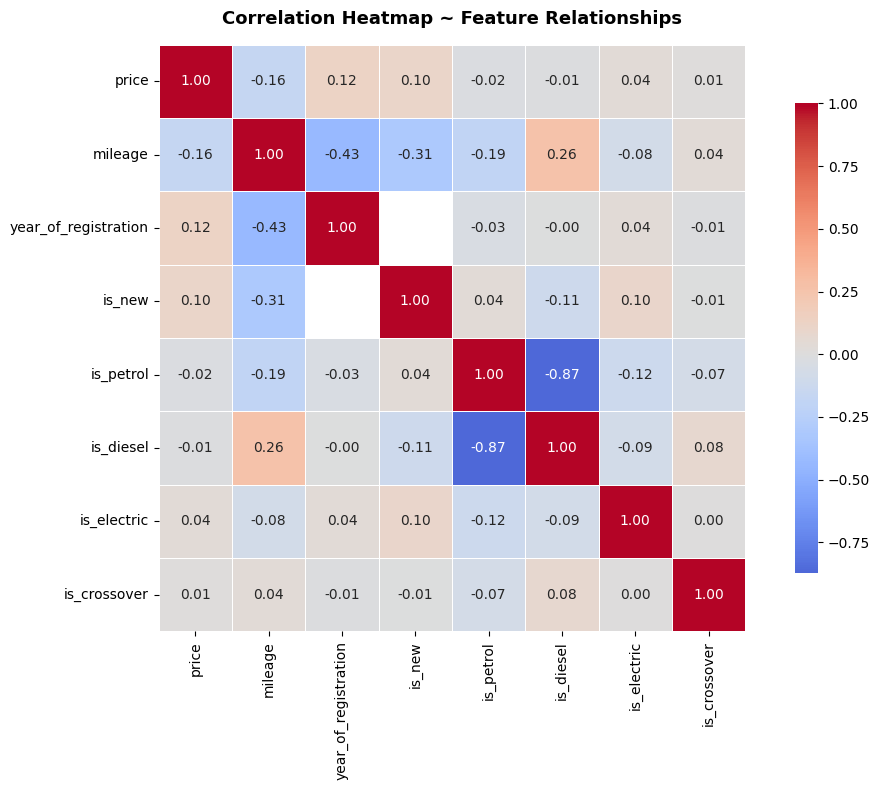

In [27]:
df_corr = df.copy()
df_corr['is_new']              = (df_corr['vehicle_condition'] == 'NEW').astype(int)
df_corr['is_petrol']           = (df_corr['fuel_type'] == 'Petrol').astype(int)
df_corr['is_diesel']           = (df_corr['fuel_type'] == 'Diesel').astype(int)
df_corr['is_electric']         = (df_corr['fuel_type'] == 'Electric').astype(int)
df_corr['is_crossover']        = df_corr['crossover_car_and_van'].fillna(False).astype(int)

corr_cols = ['price', 'mileage', 'year_of_registration',
             'is_new', 'is_petrol', 'is_diesel',
             'is_electric', 'is_crossover']

corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap ~ Feature Relationships',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

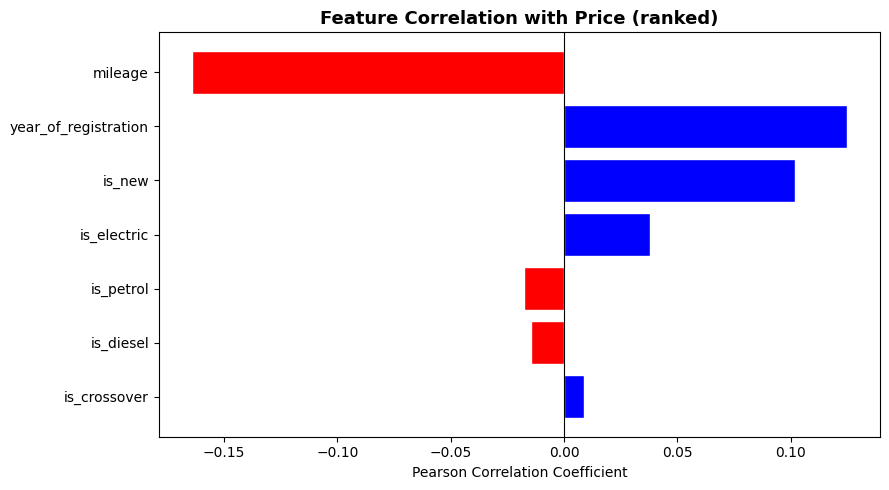


Correlation with price (ranked by strength):
  mileage                   -0.164   ↓ lower price
  year_of_registration      +0.125   ↑ higher price
  is_new                    +0.102   ↑ higher price
  is_electric               +0.038   ↑ higher price
  is_petrol                 -0.018   ↓ lower price
  is_diesel                 -0.015   ↓ lower price
  is_crossover              +0.009   ↑ higher price


In [28]:
price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['blue' if v > 0 else 'red' for v in price_corr.values]
plt.barh(price_corr.index[::-1], price_corr.values[::-1],
         color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Price (ranked)',
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nCorrelation with price (ranked by strength):")
for feat, val in price_corr.items():
    direction = "↑ higher price" if val > 0 else "↓ lower price"
    print(f"  {feat:<25} {val:+.3f}   {direction}")

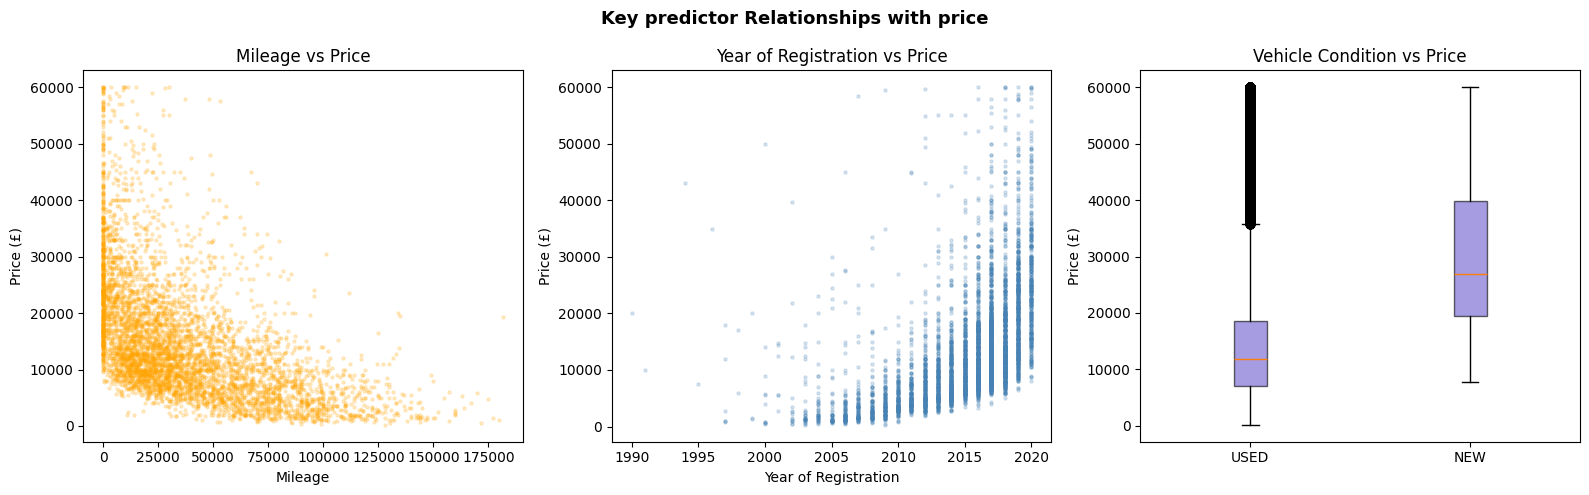

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Key predictor Relationships with price',
             fontsize=13, fontweight='bold')

plot_df = df[(df['price'] <= 60000) &
             (df['mileage'] <= 200000)].sample(5000, random_state=42)

plot_df2 = df[(df['price'] <= 60000) &
              (df['year_of_registration'] >= 1990)].sample(5000, random_state=42)


axes[0].scatter(plot_df['mileage'], plot_df['price'],
                alpha=0.2, s=5, color='orange')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Price (£)')
axes[0].set_title('Mileage vs Price')


axes[1].scatter(plot_df2['year_of_registration'], plot_df2['price'],
                alpha=0.2, s=5, color='steelblue')
axes[1].set_xlabel('Year of Registration')
axes[1].set_ylabel('Price (£)')
axes[1].set_title('Year of Registration vs Price')


axes[2].boxplot(
    [df[df['vehicle_condition'] == 'USED']['price'].clip(0, 60000),
     df[df['vehicle_condition'] == 'NEW']['price'].clip(0, 60000)],
    tick_labels=['USED', 'NEW'],
    patch_artist=True,
    boxprops=dict(facecolor='slateblue', alpha=0.6)
)
axes[2].set_ylabel('Price (£)')
axes[2].set_title('Vehicle Condition vs Price')

plt.tight_layout()
plt.show()

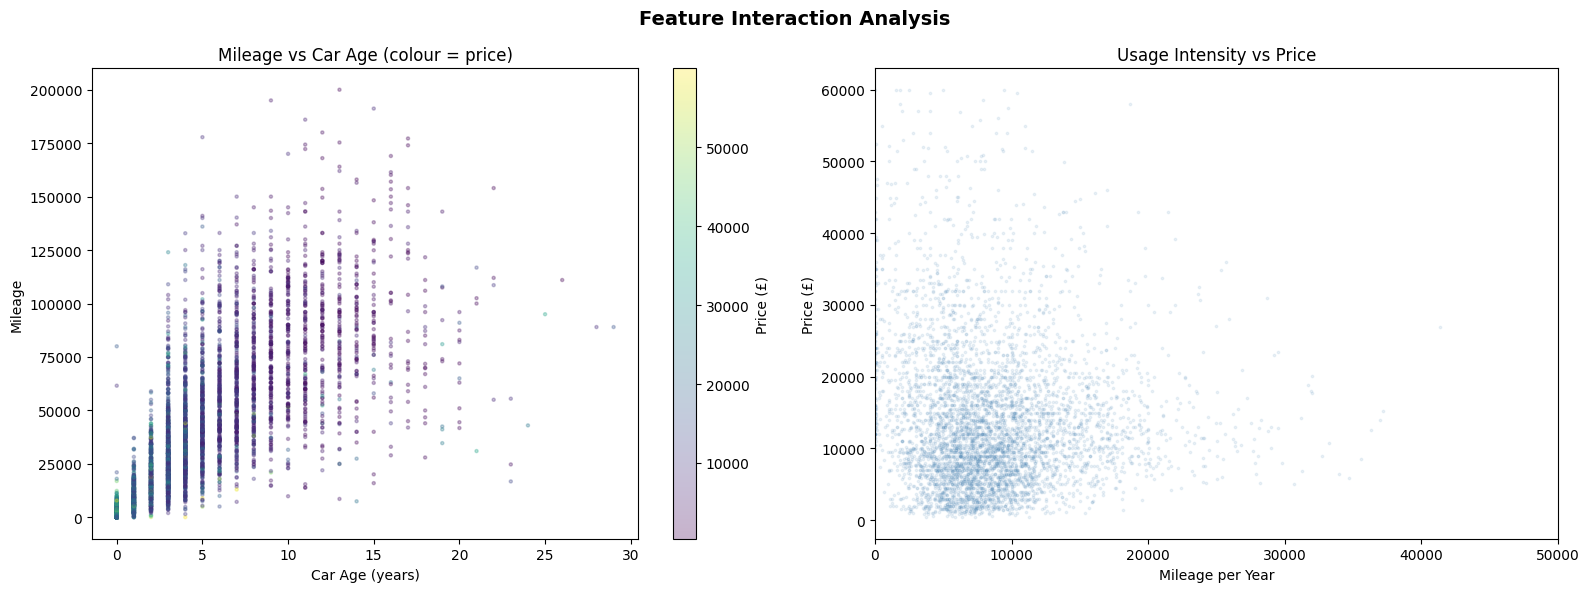

Insight: High-mileage young cars (heavy use) depreciate faster
than low-mileage old cars and mileage_per_year captures this interaction.


In [30]:
# Interaction analysis of Mileage and Car Age

temp_plot = df[(df['price'] <= 60000) &
               (df['mileage'] <= 200000) &
               (df['year_of_registration'] >= 1990)].sample(5000, random_state=42).copy()
temp_plot['car_age_temp'] = 2020 - temp_plot['year_of_registration']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Interaction Analysis', fontsize=14, fontweight='bold')

# Scatter: mileage vs car_age coloured by price
sc = axes[0].scatter(temp_plot['car_age_temp'], temp_plot['mileage'],
                     c=temp_plot['price'], cmap='viridis', alpha=0.3, s=5)
plt.colorbar(sc, ax=axes[0], label='Price (£)')
axes[0].set_xlabel('Car Age (years)')
axes[0].set_ylabel('Mileage')
axes[0].set_title('Mileage vs Car Age (colour = price)')

# Derived: mileage_per_year vs price
temp_plot['mpy'] = temp_plot['mileage'] / temp_plot['car_age_temp'].clip(lower=1)
axes[1].scatter(temp_plot['mpy'], temp_plot['price'], alpha=0.1, s=3, color='steelblue')
axes[1].set_xlabel('Mileage per Year')
axes[1].set_ylabel('Price (£)')
axes[1].set_title('Usage Intensity vs Price')
axes[1].set_xlim(0, 50000)

plt.tight_layout()
plt.show()

print("Insight: High-mileage young cars (heavy use) depreciate faster")
print("than low-mileage old cars and mileage_per_year captures this interaction.")

In [31]:
eda_summary = {
    'strongest_predictor': 'mileage (-0.16)',
    'second_predictor': 'year_of_registration (+0.10)',
    'condition_impact': 'NEW cars median £26,760 vs USED £11,875',
    'multicollinearity_warning': 'is_petrol & is_diesel correlated at -0.87',
    'rows_to_drop': {
        'abnormal_price': 1,
        'year_before_1980': 331,
        'zero_mileage_old_used': 32,
        'zero_mileage_no_year': 19,
    },
    'rows_to_fill': {
        'new_car_year': 31249,
    },
    'rows_to_investigate': {
        'mileage_above_200k': 341,
    }
}
print("EDA Summary")
print("=" * 50)
print(json.dumps(eda_summary, indent=2))

EDA Summary
{
  "strongest_predictor": "mileage (-0.16)",
  "second_predictor": "year_of_registration (+0.10)",
  "condition_impact": "NEW cars median \u00a326,760 vs USED \u00a311,875",
  "multicollinearity_warning": "is_petrol & is_diesel correlated at -0.87",
  "rows_to_drop": {
    "abnormal_price": 1,
    "year_before_1980": 331,
    "zero_mileage_old_used": 32,
    "zero_mileage_no_year": 19
  },
  "rows_to_fill": {
    "new_car_year": 31249
  },
  "rows_to_investigate": {
    "mileage_above_200k": 341
  }
}


# 2. **Data** Processing for Machine Learning

# Data Cleaning

In [32]:
# Based on investigation of missing values and logical checks, certain decisions were made for cleaning
print("Decisions for Cleaning — Cars with abnormal prices")
print(f"Total listings above £500k:         {total_above_500k}")
print(f"Dropping (£9,999,999 placeholders): {len(df[df['price']==9999999])}")
print(f"Dropping (£999,999 corrupt):        {len(df[df['price']==999999])}")
print(f"Dropping (£999,975 placeholder):    {len(df[df['price']==999975])}")
print(f"Dropping (duplicate Porsche 911):   {len(duplicate_to_drop)}")
print(f"{'─'*55}")
print(f"Total dropping:                     {total_dropping}")
print(f"Keeping (legitimate supercars):     {keeping}")
print(f"\nJustification:")
print(f"  £9,999,999 — impossible price,clear placeholder")
print(f"  £999,999   — overpriced for what they are, clear placeholder")
print(f"  £999,975   — Ferrari F40, no year, clear placeholder")
print(f"  Duplicate  — identical 1993 Porsche 911, 45 miles, £1.395M")
print(f"\n All remaining high-value listings are genuine market prices")

Decisions for Cleaning — Cars with abnormal prices
Total listings above £500k:         35
Dropping (£9,999,999 placeholders): 2
Dropping (£999,999 corrupt):        0
Dropping (£999,975 placeholder):    1
Dropping (duplicate Porsche 911):   0
───────────────────────────────────────────────────────
Total dropping:                     3
Keeping (legitimate supercars):     32

Justification:
  £9,999,999 — impossible price,clear placeholder
  £999,999   — overpriced for what they are, clear placeholder
  £999,975   — Ferrari F40, no year, clear placeholder
  Duplicate  — identical 1993 Porsche 911, 45 miles, £1.395M

 All remaining high-value listings are genuine market prices


In [33]:
# Calculate miles per year on the full clean dataset
df['car_age_temp'] = (2020 - df['year_of_registration']).clip(lower=1)
df['miles_per_year_temp'] = df['mileage'] / df['car_age_temp']

# Implausible = mileage > 200k AND miles_per_year > 50,000
implausible_mileage_idx = df[
    (df['mileage'] > 200000) &
    (df['miles_per_year_temp'] > 50000)
].index

print(f"->Implausible mileage rows to drop: {len(implausible_mileage_idx)}")
print(f"->Legitimate high-mileage rows kept: {(df['mileage'] > 200000).sum() - len(implausible_mileage_idx)}")

# Drop temp columns — we'll recreate car_age properly in feature engineering
df = df.drop(columns=['car_age_temp', 'miles_per_year_temp'])

->Implausible mileage rows to drop: 10
->Legitimate high-mileage rows kept: 117


In [34]:
# Duplicate detection on entire dataset

dup_cols = ['standard_make', 'standard_model', 'mileage', 'price', 'year_of_registration']
duplicates = df.duplicated(subset=dup_cols, keep='first')

print(f"Duplicate detection (based on make + model + mileage + price + year):")
print(f"  Total duplicates found: {duplicates.sum():,}")
print(f"  Unique rows:            {(~duplicates).sum():,}")
print(f"  Duplicate percentage:   {duplicates.mean()*100:.2f}%")

if duplicates.sum() > 0:
    # Storing duplicate indices for removal in cleaning
    duplicate_general_idx = df[duplicates].index.tolist()
    print(f"\n  These {len(duplicate_general_idx):,} duplicate rows will be removed during cleaning.")
else:
    duplicate_general_idx = []
    print("\n  No duplicates found.")

Duplicate detection (based on make + model + mileage + price + year):
  Total duplicates found: 3,798
  Unique rows:            151,596
  Duplicate percentage:   2.44%

  These 3,798 duplicate rows will be removed during cleaning.


In [35]:
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")
print("-" * 55)

# Drop 1: Corrupt prices + specific duplicate (Porsche 911)
drop_price_all = junk_price_idx + duplicate_to_drop
df_clean = df_clean.drop(index=drop_price_all)
print(f"After corrupt price drop:        {len(df_clean):,} rows (-{len(drop_price_all)})")

# Drop 2: General duplicates (same make+model+mileage+price+year)
if len(duplicate_general_idx) > 0:
    # Only drop indices that still exist
    valid_dup_idx   = [i for i in duplicate_general_idx if i in df_clean.index]
    df_clean = df_clean.drop(index=valid_dup_idx)
    print(f"After general duplicate drop:    {len(df_clean):,} rows (-{len(valid_dup_idx)})")

# Drop 3: Pre-1980 classic cars
pre1980_idx = df_clean[df_clean['year_of_registration'] < 1980].index
df_clean =df_clean.drop(index=pre1980_idx)
print(f"After pre-1980 classics drop:    {len(df_clean):,} rows (-{len(pre1980_idx)})")

# Drop 4: Old USED cars with 0 mileage (Group B)
group_b_idx = df_clean[
    (df_clean['mileage'] == 0) &
    (df_clean['vehicle_condition'] == 'USED') &
    (df_clean['year_of_registration'] < 2018)
].index
df_clean =df_clean.drop(index=group_b_idx)
print(f"After old 0-mileage USED drop:   {len(df_clean):,} rows (-{len(group_b_idx)})")

# Drop 5: No-year USED cars with 0 mileage (Group C)
group_c_idx = df_clean[
    (df_clean['mileage'] == 0) &
    (df_clean['vehicle_condition'] == 'USED') &
    (df_clean['year_of_registration'].isna())
].index
df_clean =  df_clean.drop(index=group_c_idx)
print(f"After no-year 0-mileage drop:    {len(df_clean):,} rows (-{len(group_c_idx)})")

# Drop 6: Implausible mileage (>200k miles AND >50k miles/year)
valid_impl_idx = [i for i in implausible_mileage_idx if i in df_clean.index]
df_clean = df_clean.drop(index=valid_impl_idx)
print(f"After implausible mileage drop:  {len(df_clean):,} rows (-{len(valid_impl_idx)})")

# Drop 7: Missing body_type and fuel_type ONLY (NOT standard_colour)
before = len(df_clean)
df_clean = df_clean.dropna(subset=['body_type', 'fuel_type'])
dropped_misc = before - len(df_clean)
print(f"After missing body/fuel drop:    {len(df_clean):,} rows (-{dropped_misc})")

print("-" * 55)
print(f"\nOriginal dataset:   {len(df):,} rows")
print(f"Cleaned dataset:    {len(df_clean):,} rows")
print(f"Total removed:      {len(df) - len(df_clean):,} rows ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")
print(f"Data retained:      {len(df_clean)/len(df)*100:.1f}%")

Starting shape: (155394, 12)
-------------------------------------------------------
After corrupt price drop:        155,391 rows (-3)
After general duplicate drop:    151,593 rows (-3798)
After pre-1980 classics drop:    151,466 rows (-127)
After old 0-mileage USED drop:   151,453 rows (-13)
After no-year 0-mileage drop:    151,446 rows (-7)
After implausible mileage drop:  151,436 rows (-10)
After missing body/fuel drop:    150,957 rows (-479)
-------------------------------------------------------

Original dataset:   155,394 rows
Cleaned dataset:    150,957 rows
Total removed:      4,437 rows (2.86%)
Data retained:      97.1%


In [36]:
# Dealing with improper years of registration

# Fill NEW cars with 2020
new_mask = df_clean['vehicle_condition'] == 'NEW'
df_clean.loc[new_mask, 'year_of_registration'] = \
    df_clean.loc[new_mask, 'year_of_registration'].fillna(2020)

# Drop remaining USED cars still missing year
before = len(df_clean)
df_clean = df_clean.dropna(subset=['year_of_registration'])
print(f"year_of_registration: filled {new_mask.sum():,} NEW cars with 2020")
print(f"                      dropped {before - len(df_clean):,} USED rows with unknown year")

# reg_code, drop entire column because not useful plus privacy concern
df_clean = df_clean.drop(columns=['reg_code'])
print(f"\nreg_code: column dropped entirely (privacy concern, not a model feature)")

# impute NEW cars that have milage missing with 0, drop remaining
new_mileage_mask = (df_clean['vehicle_condition'] == 'NEW') & (df_clean['mileage'].isna())
df_clean.loc[new_mileage_mask, 'mileage'] = 0
before = len(df_clean)
df_clean = df_clean.dropna(subset=['mileage'])
print(f"\nmileage: filled {new_mileage_mask.sum()} NEW cars with 0")
print(f"         dropped {before - len(df_clean):,} remaining rows with missing mileage")

# standard_colour, NOT imputed here, found leakage when trying to implement before data splitting
print(f"\nstandard_colour: {df_clean['standard_colour'].isna().sum()} missing values")
print(f"  Will be imputed after split using training-set mode to  prevent")

# Final check
print("\n" + "=" * 45)
print("Mising Values Remaining:")
missing = df_clean.isnull().sum()
remaining = missing[missing > 0]
print(remaining if len(remaining) > 0 else "  None (except standard_colour — handled after split)")
print(f"\nDataset shape: {df_clean.shape}")

year_of_registration: filled 8,987 NEW cars with 2020
                      dropped 626 USED rows with unknown year

reg_code: column dropped entirely (privacy concern, not a model feature)

mileage: filled 0 NEW cars with 0
         dropped 33 remaining rows with missing mileage

standard_colour: 1897 missing values
  Will be imputed after split using training-set mode to  prevent

Mising Values Remaining:
standard_colour    1897
dtype: int64

Dataset shape: (150298, 11)


In [37]:
# Drop ID column, not useful plus privacy concern
df_clean = df_clean.drop(columns=['public_reference'])
print(f"Dropped public_reference (ID column)")

# Drop crossover_car_and_van, low correlation
df_clean = df_clean.drop(columns=['crossover_car_and_van'])
print(f"Dropped crossover_car_and_van (correlation with price: 0.010 — below threshold)")

# Engineer car_age, important FE
DATASET_YEAR = 2020
df_clean['car_age'] = DATASET_YEAR - df_clean['year_of_registration']

# Engineer mileage_per_year, important FE
df_clean['mileage_per_year'] = df_clean['mileage'] / df_clean['car_age'].clip(lower=1) #cannot divide by zeeero

# Clip mileage_per_year to 50,000 because values above this are unrealistic and probably noise
before_clip = (df_clean['mileage_per_year'] > 50000).sum()
df_clean['mileage_per_year'] = df_clean['mileage_per_year'].clip(upper=50000)
print(f"mileage_per_year: clipped {before_clip} extreme values to 50,000 max")

# Drop year_of_registration (replaced by car_age)
df_clean = df_clean.drop(columns=['year_of_registration'])

print(f"\ncar_age:            min={df_clean['car_age'].min():.0f}  max={df_clean['car_age'].max():.0f}  mean={df_clean['car_age'].mean():.1f}")
print(f"mileage_per_year:   min={df_clean['mileage_per_year'].min():.0f}  max={df_clean['mileage_per_year'].max():.0f}  mean={df_clean['mileage_per_year'].mean():.0f}")
print(f"\nCurrent shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Dropped public_reference (ID column)
Dropped crossover_car_and_van (correlation with price: 0.010 — below threshold)
mileage_per_year: clipped 67 extreme values to 50,000 max

car_age:            min=0  max=40  mean=4.6
mileage_per_year:   min=0  max=50000  mean=8091

Current shape: (150298, 10)
Columns: ['mileage', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'price', 'body_type', 'fuel_type', 'car_age', 'mileage_per_year']


# Data Splitting

In [38]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

total = len(df_clean)
print(f"Train:      {len(X_train):,} ({len(X_train)/total*100:.1f}%)")
print(f"Validation: {len(X_val):,}  ({len(X_val)/total*100:.1f}%)")
print(f"Test:       {len(X_test):,}  ({len(X_test)/total*100:.1f}%)")

Train:      105,208 (70.0%)
Validation: 15,030  (10.0%)
Test:       30,060  (20.0%)


In [39]:
# Distribution check to verify train/val/test splits are similar
# Check price (target) distribution
print(f"\n{'Metric':<20} {'Train':>12} {'Val':>12} {'Test':>12}")
print("-" * 60)
for stat_name in ['mean', '50%', 'std', 'min', 'max']:
    t = y_train.describe()[stat_name]
    v = y_val.describe()[stat_name]
    te = y_test.describe()[stat_name]
    label = stat_name if stat_name != '50%' else 'median'
    print(f"  Price {label:<12} £{t:>10,.0f} £{v:>10,.0f} £{te:>10,.0f}")

# Check key categorical distributions
print(f"\nVehicle condition distribution:")
for name, X in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    dist = X['vehicle_condition'].value_counts(normalize=True)
    parts = [f"{k}: {v:.1%}" for k, v in dist.items()]
    print(f"  {name:<6} {', '.join(parts)}")

print(f"\nTop 5 makes — frequency comparison:")
top5_makes = X_train['standard_make'].value_counts().head(5).index
for make in top5_makes:
    t_pct = (X_train['standard_make'] == make).mean()
    v_pct = (X_val['standard_make'] == make).mean()
    te_pct = (X_test['standard_make'] == make).mean()
    print(f"  {make:<20} Train: {t_pct:.2%}  Val: {v_pct:.2%}  Test: {te_pct:.2%}")



Metric                      Train          Val         Test
------------------------------------------------------------
  Price mean         £    16,735 £    16,792 £    16,761
  Price median       £    12,396 £    12,399 £    12,491
  Price std          £    23,579 £    19,735 £    22,267
  Price min          £       180 £       295 £       250
  Price max          £ 2,850,000 £   439,999 £ 1,590,000

Vehicle condition distribution:
  Train  USED: 94.0%, NEW: 6.0%
  Val    USED: 94.1%, NEW: 5.9%
  Test   USED: 94.1%, NEW: 5.9%

Top 5 makes — frequency comparison:
  BMW                  Train: 9.56%  Val: 9.88%  Test: 9.31%
  Audi                 Train: 8.85%  Val: 8.84%  Test: 8.89%
  Volkswagen           Train: 8.41%  Val: 8.33%  Test: 8.58%
  Vauxhall             Train: 8.37%  Val: 8.41%  Test: 8.44%
  Mercedes-Benz        Train: 8.02%  Val: 8.13%  Test: 7.98%


# Encoding

In [40]:
# Impute missing standard_colour using TRAINING data mode only

colour_mode_train=X_train['standard_colour'].mode()[0]

for name, X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    missing_before = X['standard_colour'].isna().sum()
    X['standard_colour'] = X['standard_colour'].fillna(colour_mode_train)
    print(f"  {name}: filled {missing_before} missing colours with '{colour_mode_train}'")

print(f"\n  Mode computed from training data ONLY (prevents data leakage)")

  X_train: filled 1326 missing colours with 'Black'
  X_val: filled 196 missing colours with 'Black'
  X_test: filled 375 missing colours with 'Black'

  Mode computed from training data ONLY (prevents data leakage)


In [41]:
# Target encoding with K-fold approach and frequency features

global_mean = y_train.mean()
smoothing = 50

def smoothed_target_encode(train_X, train_y, val_X, test_X, col, smoothing, global_mean):
    """
    Apply smoothed target encoding with K-fold approach for training set.
    - Training set: each row is encoded using only out-of-fold statistics
    - Val/Test sets: encoded using full training set statistics
    """
    encoded_col = f'{col}_encoded'
    freq_col = f'{col}_freq'

    # K-fold encoding for training set (prevents within-train leakage)
    train_X[encoded_col] = global_mean  # default
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, oof_idx in kf.split(train_X):
        # Compute statistics using only the training fold
        fold_data = train_X.iloc[train_idx].join(train_y)
        stats = fold_data.groupby(col)['price'].agg(['mean', 'count'])
        stats['smoothed'] = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)

        # Apply to the out-of-fold rows
        train_X.iloc[oof_idx, train_X.columns.get_loc(encoded_col)] = (
            train_X.iloc[oof_idx][col].map(stats['smoothed']).fillna(global_mean).values
        )

    # Full-data encoding for val/test
    full_stats  = train_X.join(train_y).groupby(col)['price'].agg(['mean', 'count'])
    full_stats['smoothed'] = (full_stats['count'] * full_stats['mean'] + smoothing * global_mean) / (full_stats['count'] + smoothing)
    full_means = full_stats['smoothed']

    val_X[encoded_col]  =val_X[col].map(full_means).fillna(global_mean)
    test_X[encoded_col] =test_X[col].map(full_means).fillna(global_mean)

    # Frequency encoding (how common is each category)
    freq_map = train_X[col].value_counts(normalize=True)
    train_X[freq_col] = train_X[col].map(freq_map).fillna(0)
    val_X[freq_col]   =  val_X[col].map(freq_map).fillna(0)
    test_X[freq_col]  =test_X[col].map(freq_map).fillna(0)

    return train_X, val_X, test_X

# Apply  encoding to standard_make
X_train, X_val, X_test = smoothed_target_encode(
    X_train, y_train, X_val, X_test, 'standard_make', smoothing, global_mean
)

# Appl encoding to standard_model
X_train, X_val, X_test = smoothed_target_encode(
    X_train, y_train, X_val, X_test, 'standard_model', smoothing, global_mean
)

# Dropping original categorical columns
X_train = X_train.drop(columns=['standard_make', 'standard_model'])
X_val   = X_val.drop(columns=['standard_make', 'standard_model'])
X_test  = X_test.drop(columns=['standard_make', 'standard_model'])

print("Target encoding complete...")
print(f"  Smoothing factor: {smoothing}")
print(f"  K-fold encoding: 5-fold on training set (prevents within-train leakage)")
print(f"  Frequency features: added for make and model")
print(f"  Global mean price: £{global_mean:,.0f}")


Target encoding complete...
  Smoothing factor: 50
  K-fold encoding: 5-fold on training set (prevents within-train leakage)
  Frequency features: added for make and model
  Global mean price: £16,735


In [42]:
# One-hot encode using ONLY training data
ohe_cols = ['fuel_type', 'body_type', 'vehicle_condition', 'standard_colour']
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[ohe_cols])

ohe_feature_names = ohe.get_feature_names_out(ohe_cols).tolist()

# Transform each set independently
for name, X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    encoded = ohe.transform(X[ohe_cols])
    encoded_df = pd.DataFrame(encoded, columns=ohe_feature_names, index=X.index)

    # Dropping original columns and add encoded ones
    X_temp = X.drop(columns=ohe_cols)
    X_temp = pd.concat([X_temp, encoded_df], axis=1)

    # Ensure integ  er type for encoded columns
    X_temp[ohe_feature_names] = X_temp[ohe_feature_names].astype(int)

    if name == 'X_train':
        X_train=X_temp
    elif name == 'X_val':
        X_val = X_temp
    else:
        X_test = X_temp

print("One-hot encoding complete...")
print(f"\nFinal shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

print(f"\nColumn consistency check:")
print(f"  Train cols == Val cols:  {list(X_train.columns) == list(X_val.columns)}")
print(f"  Train cols == Test cols: {list(X_train.columns) == list(X_test.columns)}")


One-hot encoding complete...

Final shapes:
  X_train: (105208, 49)
  X_val:   (15030, 49)
  X_test:  (30060, 49)

Column consistency check:
  Train cols == Val cols:  True
  Train cols == Test cols: True


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Feature Engineering

In [43]:
temp_corr = X_train.copy()
temp_corr['price'] = y_train.values

# Full correlation with price for every feature
corr_matrix = temp_corr.corr()
price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)

print(f"{'Rank':<6} {'Feature':<40} {'Correlation':>12} {'Direction'}")
print("-" * 60)

for rank, (feat, val) in enumerate(price_corr.items(), 1):
    strength  = "🔴 Strong" if abs(val) > 0.4 else \
                "🟡 Moderate" if abs(val) > 0.2 else \
                "⚪ Weak"
    print(f"{rank:<6} {feat:<40} {val:>+.4f}       {strength}")

print("-" * 60)
print(f"\nTotal features: {len(price_corr)}")
print(f"Strong (>0.4):   {(price_corr.abs() > 0.4).sum()}")
print(f"Moderate (>0.2): {((price_corr.abs() > 0.2) & (price_corr.abs() <= 0.4)).sum()}")
print(f"Weak (<0.2):     {(price_corr.abs() < 0.2).sum()}")

Rank   Feature                                   Correlation Direction
------------------------------------------------------------
1      standard_model_encoded                   +0.5518       🔴 Strong
2      standard_make_encoded                    +0.5499       🔴 Strong
3      mileage                                  -0.3069       🟡 Moderate
4      car_age                                  -0.2740       🟡 Moderate
5      body_type_Hatchback                      -0.2333       🟡 Moderate
6      vehicle_condition_USED                   -0.1960       ⚪ Weak
7      mileage_per_year                         -0.1721       ⚪ Weak
8      body_type_Coupe                          +0.1648       ⚪ Weak
9      body_type_SUV                            +0.1433       ⚪ Weak
10     standard_model_freq                      -0.1375       ⚪ Weak
11     fuel_type_Petrol Plug-in Hybrid          +0.0935       ⚪ Weak
12     body_type_Convertible                    +0.0746       ⚪ Weak
13     fuel_type_Electri

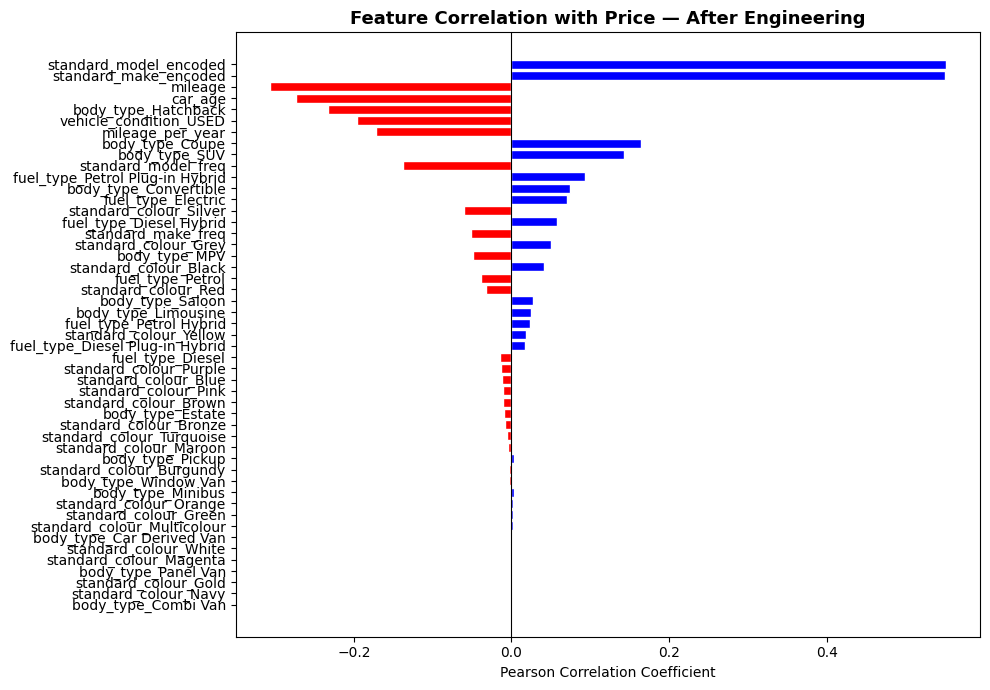


Top 10 correlations with price:
standard_model_encoded    +0.5518
standard_make_encoded     +0.5499
mileage                   -0.3069
car_age                   -0.2740
body_type_Hatchback       -0.2333
vehicle_condition_USED    -0.1960
mileage_per_year          -0.1721
body_type_Coupe           +0.1648
body_type_SUV             +0.1433
standard_model_freq       -0.1375
Name: price, dtype: object


In [44]:
price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))

colors=['blue' if v > 0 else   'red' for v in price_corr.values]
plt.barh(price_corr.index[::-1], price_corr.values[::-1],
         color=colors[::-1], edgecolor ='white')
plt.axvline(0, color='black', linewidth=0.8)

plt.title('Feature Correlation with Price — After Engineering',
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nTop 10 correlations with price:")
print(price_corr.head(10).apply(lambda x: f"{x:+.4f}"))

In [45]:
# Dropping NaN correlation columns (zero variance)
nan_corr_cols = ['fuel_type_Natural Gas', 'standard_colour_Indigo']

# Check they exist before dropping
nan_corr_cols = [c for c in nan_corr_cols if c in X_train.columns]

X_train = X_train.drop(columns=nan_corr_cols)
X_val   = X_val.drop(columns=nan_corr_cols)
X_test  = X_test.drop(columns=nan_corr_cols)
print(f"Dropped zero-variance columns: {nan_corr_cols}")

# checks colour columns
colour_cols = [c for c in X_train.columns if c.startswith('standard_colour')]
colour_corr = price_corr[colour_cols].abs().sort_values(ascending=False)

print(f"\nAll colour column correlations with price:")
for col, val in colour_corr.items():
    print(f"  {col:<40} {val:+.4f}")

print(f"\nMax colour correlation: {colour_corr.max():.4f}")
print(f"Mean colour correlation: {colour_corr.mean():.4f}")

Dropped zero-variance columns: []

All colour column correlations with price:
  standard_colour_Silver                   +0.0597
  standard_colour_Grey                     +0.0497
  standard_colour_Black                    +0.0412
  standard_colour_Red                      +0.0318
  standard_colour_Yellow                   +0.0191
  standard_colour_Purple                   +0.0126
  standard_colour_Blue                     +0.0122
  standard_colour_Pink                     +0.0106
  standard_colour_Brown                    +0.0103
  standard_colour_Bronze                   +0.0076
  standard_colour_Turquoise                +0.0054
  standard_colour_Maroon                   +0.0048
  standard_colour_Burgundy                 +0.0035
  standard_colour_Orange                   +0.0019
  standard_colour_Green                    +0.0019
  standard_colour_Multicolour              +0.0018
  standard_colour_White                    +0.0016
  standard_colour_Magenta                  +0.0013
  st

In [46]:
# all of the colour correlations are below 0.06 so effectively noise
# dropping them reduces dimensionality from 51 to ~37 features
# and removes columns that could introduce noise into the model

X_train = X_train.drop(columns=colour_cols)
X_val   = X_val.drop(columns=colour_cols)
X_test  = X_test.drop(columns=colour_cols)

print(f"\nColour columns dropped: {len(colour_cols)}")
print(f"Feature count after colour drop: {X_train.shape[1]}")

# Drop commercial vehicle body types (low corr, not relevant to car pricing)
commercial_cols = [
    'body_type_Window Van', 'body_type_Chassis Cab',
    'body_type_Car Derived Van', 'body_type_Panel Van',
    'body_type_Combi Van', 'body_type_Minibus'
]
commercial_cols = [c for c in commercial_cols if c in X_train.columns]

X_train = X_train.drop(columns=commercial_cols)
X_val   = X_val.drop(columns=commercial_cols)
X_test  = X_test.drop(columns=commercial_cols)

print(f"\nDropped commercial vehicle body types: {commercial_cols}")
print(f"Final feature count: {X_train.shape[1]}")


Colour columns dropped: 20
Feature count after colour drop: 29

Dropped commercial vehicle body types: ['body_type_Window Van', 'body_type_Car Derived Van', 'body_type_Panel Van', 'body_type_Combi Van', 'body_type_Minibus']
Final feature count: 24


In [47]:
print("Final Feature Set Summary")
print("=" * 55)

# Check no missing values in any split
for name, X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    missing = X.isnull().sum().sum()
    dtypes  = X.dtypes.value_counts().to_dict()
    print(f"\n{name}:")
    print(f"  Shape:         {X.shape}")
    print(f"  Missing vals:  {missing}")
    print(f"  Dtypes:        {dtypes}")

print(f"\nAll columns ({len(X_train.columns)}):")
for col in X_train.columns:
    print(f"  {col}")

Final Feature Set Summary

X_train:
  Shape:         (105208, 24)
  Missing vals:  0
  Dtypes:        {dtype('int64'): 17, dtype('float64'): 7}

X_val:
  Shape:         (15030, 24)
  Missing vals:  0
  Dtypes:        {dtype('int64'): 17, dtype('float64'): 7}

X_test:
  Shape:         (30060, 24)
  Missing vals:  0
  Dtypes:        {dtype('int64'): 17, dtype('float64'): 7}

All columns (24):
  mileage
  car_age
  mileage_per_year
  standard_make_encoded
  standard_make_freq
  standard_model_encoded
  standard_model_freq
  fuel_type_Diesel
  fuel_type_Diesel Hybrid
  fuel_type_Diesel Plug-in Hybrid
  fuel_type_Electric
  fuel_type_Petrol
  fuel_type_Petrol Hybrid
  fuel_type_Petrol Plug-in Hybrid
  body_type_Convertible
  body_type_Coupe
  body_type_Estate
  body_type_Hatchback
  body_type_Limousine
  body_type_MPV
  body_type_Pickup
  body_type_SUV
  body_type_Saloon
  vehicle_condition_USED


# Scaling

In [48]:
# StandardScaler has no significant effect on tree-based model
# it's being applied here only for the Ridge regression baseline

scale_cols = ['mileage', 'car_age', 'mileage_per_year',
              'standard_make_encoded', 'standard_model_encoded',
              'standard_make_freq', 'standard_model_freq']

scale_cols = [c for c in scale_cols if c in X_train.columns]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Feature scaling complete...")
print(f"Scaler fitted on training data (prevents data leakage)")
print(f"\nScaled columns: {scale_cols}")
print(f"\nPost-scaling stats (X_train):")
print(X_train[scale_cols].describe().round(4))

Feature scaling complete...
Scaler fitted on training data (prevents data leakage)

Scaled columns: ['mileage', 'car_age', 'mileage_per_year', 'standard_make_encoded', 'standard_model_encoded', 'standard_make_freq', 'standard_model_freq']

Post-scaling stats (X_train):
        mileage   car_age  mileage_per_year  standard_make_encoded  \
count 105208.00 105208.00         105208.00              105208.00   
mean       0.00     -0.00              0.00                   0.00   
std        1.00      1.00              1.00                   1.00   
min       -1.12     -1.11             -1.47                  -0.80   
25%       -0.78     -0.63             -0.63                  -0.50   
50%       -0.26     -0.39             -0.11                  -0.27   
75%        0.56      0.32              0.47                   0.35   
max       10.83      8.43              7.63                  12.84   

       standard_model_encoded  standard_make_freq  standard_model_freq  
count               105208

Log transformation computed...

Original price distribution:
  Mean:   £16,735
  Median: £12,396
  Skew:   37.989

Log-transformed price distribution:
  Mean:   9.3678
  Median: 9.4253
  Skew:   -0.322


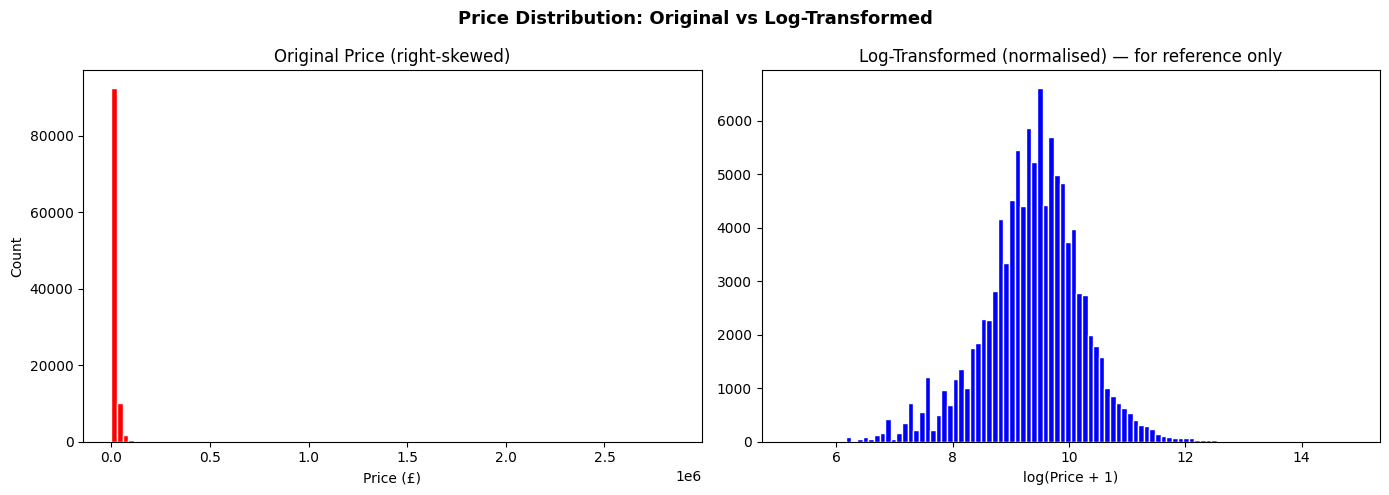

In [49]:
# Log analysis
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

print("Log transformation computed...")
print(f"\nOriginal price distribution:")
print(f"  Mean:   £{y_train.mean():,.0f}")
print(f"  Median: £{y_train.median():,.0f}")
print(f"  Skew:   {y_train.skew():.3f}")

print(f"\nLog-transformed price distribution:")
print(f"  Mean:   {y_train_log.mean():.4f}")
print(f"  Median: {y_train_log.median():.4f}")
print(f"  Skew:   {y_train_log.skew():.3f}")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution: Original vs Log-Transformed', fontsize=13, fontweight='bold')

axes[0].hist(y_train, bins=100, color='red', edgecolor='white')
axes[0].set_title('Original Price (right-skewed)')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Count')

axes[1].hist(y_train_log, bins=100, color='blue', edgecolor='white')
axes[1].set_title('Log-Transformed (normalised) — for reference only')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [50]:
print("Data Processing Complete")
print("=" * 55)
print(f"\nDataset journey:")
print(f"  Original rows:         {len(df):,}")
print(f"  After cleaning:        {len(df_clean):,}")
print(f"  Rows removed:          {len(df)-len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")

print(f"\nFinal feature set:     {X_train.shape[1]} features")
print(f"  Train:               {X_train.shape}")
print(f" Validation:          {X_val.shape}")
print(f"  Test:                {X_test.shape}")

print(f"\nAll features:")
for col in X_train.columns:
    print(f"  {col}")

Data Processing Complete

Dataset journey:
  Original rows:         155,394
  After cleaning:        150,298
  Rows removed:          5,096 (3.3%)

Final feature set:     24 features
  Train:               (105208, 24)
 Validation:          (15030, 24)
  Test:                (30060, 24)

All features:
  mileage
  car_age
  mileage_per_year
  standard_make_encoded
  standard_make_freq
  standard_model_encoded
  standard_model_freq
  fuel_type_Diesel
  fuel_type_Diesel Hybrid
  fuel_type_Diesel Plug-in Hybrid
  fuel_type_Electric
  fuel_type_Petrol
  fuel_type_Petrol Hybrid
  fuel_type_Petrol Plug-in Hybrid
  body_type_Convertible
  body_type_Coupe
  body_type_Estate
  body_type_Hatchback
  body_type_Limousine
  body_type_MPV
  body_type_Pickup
  body_type_SUV
  body_type_Saloon
  vehicle_condition_USED


---
# 3. Model Building

## Algorithm Selection Justification

**Two regression algorithms** are compared, spanning linear and tree-based approaches:

| Algorithm | Type | Why Selected |
|-----------|------|-------------|
| **Ridge Regression** | Linear (L2 regularised) | Baseline — establishes the performance ceiling for linear models. Ridge handles multicollinearity from one-hot encoded features and provides a simple, interpretable benchmark. |
| **Random Forest** | Ensemble of decision trees (bagging) | Bootstrap aggregation reduces variance compared to a single tree. Natively handles non-linear relationships and feature interactions in car pricing. Robust, interpretable via SHAP, and requires minimal hyperparameter tuning. |

The best performing model will be chosen for tuning and then a final model comparison will be made to select the overall best model

In [51]:
print("Baseline model using Ridge Regression")
print("=" * 50)

# Scaling all features for Ridge (binary + continuous on same scale)
ridge_scaler = SS()
X_train_scaled = pd.DataFrame(
    ridge_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    ridge_scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

# Train Ridge on RAW prices (not log-transformed)
print("\nTraining Ridge Regression on raw prices...")
lr_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0])
lr_model.fit(X_train_scaled, y_train)
print(f"  Best alpha selected: {lr_model.alpha_}")

# Predictions
lr_preds = lr_model.predict(X_val_scaled)
lr_preds = np.clip(lr_preds, 0, None)  # prices can't be negative

# Metrics
lr_r2   = r2_score(y_val, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
lr_mae  = mean_absolute_error(y_val, lr_preds)

# Train metrics
lr_train_preds = lr_model.predict(X_train_scaled)
lr_train_preds = np.clip(lr_train_preds, 0, None)
lr_train_r2    = r2_score(y_train, lr_train_preds)

print(f"\n Ridge Regression Done~")
print(f"  Train R²: {lr_train_r2:.4f}")
print(f"  Val R²:   {lr_r2:.4f}")
print(f"  RMSE:     £{lr_rmse:,.0f}")
print(f"  MAE:      £{lr_mae:,.0f}")
print(f"  Overfit:  {lr_train_r2 - lr_r2:.4f}")

if lr_train_r2 - lr_r2 < 0.05:
    print(f"\n  Bias/Variance: Well fitted (train ≈ val)")
elif lr_train_r2 - lr_r2 > 0.1:
    print(f"\n  Bias/Variance: Overfitting detected (train >> val)")
else:
    print(f"\n  Bias/Variance: Slight overfitting")

# Initialize results list and model storage
results = []
trained_models = {}

results.append({
    "Model": "Ridge Regression (baseline)",
    "R² Score": lr_r2,
    "RMSE": lr_rmse,
    "MAE": lr_mae,
    "Train R²": lr_train_r2
})

trained_models["Linear Regression"] = lr_model

Baseline model using Ridge Regression

Training Ridge Regression on raw prices...
  Best alpha selected: 1.0

 Ridge Regression Done~
  Train R²: 0.4662
  Val R²:   0.7088
  RMSE:     £10,650
  MAE:      £5,146
  Overfit:  -0.2425

  Bias/Variance: Well fitted (train ≈ val)



  Training set:   (105208, 24)
  Validation set: (15030, 24)
  Test set:       (30060, 24)

 Training Random Forest...
Random Forest Done!

 Final Results:
                      Model  R² Score     RMSE     MAE  Train R²
              Random Forest      0.91  5937.87 2322.25      0.72
Ridge Regression (baseline)      0.71 10649.87 5145.99      0.47

Overfitting check (Train R² vs Val R²):
  Random Forest Train R²: 0.7245  Val R²: 0.9095  Gap: -0.1850


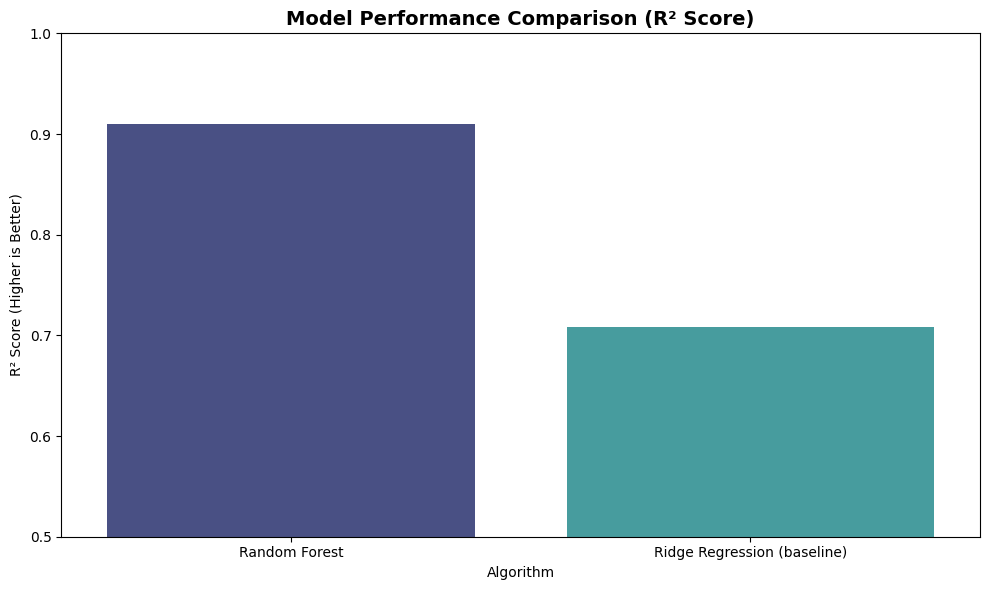

In [52]:
# Safteya nd sanity checks
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert not X_train.isnull().any().any(), "NaNs in X_train"
assert not X_val.isnull().any().any(), "NaNs in X_val"

# Ensure all sets are numeric with identical columns
X_train = X_train.select_dtypes(include=[np.number])
train_feature_cols = X_train.columns.tolist()
X_val  = X_val[train_feature_cols]
X_test = X_test[train_feature_cols]

print(f"\n  Training set:   {X_train.shape}")
print(f"  Validation set: {X_val.shape}")
print(f"  Test set:       {X_test.shape}")

# 1. RANDOM FOREST
print("\n Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)

trained_models["Random Forest"] = rf_model

rf_preds = rf_model.predict(X_val)
rf_train_preds = rf_model.predict(X_train)

results.append({
    "Model": "Random Forest",
    "R² Score": r2_score(y_val, rf_preds),
    "RMSE": np.sqrt(mean_squared_error(y_val, rf_preds)),
    "MAE": mean_absolute_error(y_val, rf_preds),
    "Train R²": r2_score(y_train, rf_train_preds)
})

print("Random Forest Done!")

# Results
results_df=  pd.DataFrame(results).sort_values(by="R² Score", ascending=False)

print("\n Final Results:")
print(results_df.to_string(index=False))
print("=" * 50)
# Overfitting check
print("\nOverfitting check (Train R² vs Val R²):")
for name, model in trained_models.items():
    if name == "Linear Regression":
        continue
    train_preds = model.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    val_r2   = [r['R² Score'] for r in results if r['Model'] == name]
    val_r2   = val_r2[0] if val_r2 else None
    print(f"  {name:<12} Train R²: {train_r2:.4f}  Val R²: {val_r2:.4f}  Gap: {train_r2 - val_r2:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df,
    x='Model',
    y='R² Score',
    hue='Model',
    palette='mako',
    legend=False
)

plt.title('Model Performance Comparison (R² Score)', fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.ylabel('R² Score (Higher is Better)')
plt.xlabel('Algorithm')

plt.tight_layout()
plt.show()

In [53]:
# Random Forest tuning
# Strategy: use a 25% sample for speed, fewer large-tree combos,
# focus on the parameters that actually matter for RF performance.
print("Starting RandomizedSearchCV on Random Forest...")
print("15 combinations × 3 folds = 45 fits (on 25% sample for speed)\n")

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [20, 25, 30, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2', 0.3, 0.5]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Subsample to speed up tuning phase
X_train_sample = X_train.sample(frac=0.25, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

search.fit(X_train_sample, y_train_sample)

print(f"\nBest CV R² Score on sample: {search.best_score_:.4f}")
print("Best parameters:")
for k, v in search.best_params_.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Now refit the best config on FULL training data for maximum performance
print("\nRefitting best params on full training set...")
best_rf = RandomForestRegressor(
    **search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
print("Done!")


Starting RandomizedSearchCV on Random Forest...
15 combinations × 3 folds = 45 fits (on 25% sample for speed)

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV R² Score on sample: 0.8379
Best parameters:
  max_depth: 20
  max_features: 0.5000
  min_samples_leaf: 2
  min_samples_split: 9
  n_estimators: 200

Refitting best params on full training set...
Done!


In [54]:
# Evaluate the tuned Random Forest (refitted on full data above)
print("Tuned RANDOM FOREST — Validation Results")
print("=" * 50)
print(f"  Best params: {search.best_params_}")

# Validation performance
tuned_val_preds   = best_rf.predict(X_val)
tuned_train_preds = best_rf.predict(X_train)
tuned_r2     = r2_score(y_val, tuned_val_preds)
tuned_rmse   = np.sqrt(mean_squared_error(y_val, tuned_val_preds))
tuned_mae = mean_absolute_error(y_val, tuned_val_preds)
tuned_train_r2 = r2_score(y_train, tuned_train_preds)

print(f"  Train R²:    {tuned_train_r2:.4f}")
print(f"  Val R²:      {tuned_r2:.4f}")
print(f"  RMSE:        £{tuned_rmse:,.0f}")
print(f"  MAE:         £{tuned_mae:,.0f}")
print(f"  Overfit gap: {tuned_train_r2 - tuned_r2:.4f}")

if tuned_train_r2 - tuned_r2 < 0.02:
    print(f"\n Well generalised and minimal overfitting")
elif tuned_train_r2 - tuned_r2 < 0.05:
    print(f"\n Slight overfitting")
else:
    print(f"\n Overfitting detected")

results.append({
    "Model": "Random Forest Tuned",
    "R² Score": tuned_r2,
    "RMSE": tuned_rmse,
    "MAE": tuned_mae,
    "Train R²": tuned_train_r2
})

trained_models["Random Forest Tuned"] = best_rf

Tuned RANDOM FOREST — Validation Results
  Best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 200}
  Train R²:    0.8342
  Val R²:      0.9255
  RMSE:        £5,388
  MAE:         £2,128
  Overfit gap: -0.0913

 Well generalised and minimal overfitting


In [55]:
# Hyperparameter Tuning impact analysis — Random Forest
print("Hyperparameter tuning on RANDOM FOREST, Before Vs. After")
print("=" * 50)
default_rf = [r for r in results if r['Model'] == 'Random Forest'][0]
tuned_rf = [r for r in results if r['Model'] == 'Random Forest Tuned'][0]
print(f"\n{'Metric':<20} {'Default Random Forest':>18} {'Tuned Random Forest':>18} {'Improvement':>15}")
print("-" * 75)
print(f"   {'Val R²':<18} {default_rf['R² Score']:>18.4f}  {tuned_rf['R² Score']:>18.4f} "
      f"{tuned_rf['R² Score']  - default_rf['R² Score']:>+14.4f}")
print(f"  {'RMSE':<18} £{default_rf['RMSE']:>16,.0f}  £{tuned_rf['RMSE']:>16,.0f} "
      f"£{tuned_rf['RMSE'] -  default_rf['RMSE']:>+13,.0f}")
print(f"  {'MAE':<18} £{default_rf['MAE']:>16,.0f}  £{tuned_rf['MAE']:>16,.0f} "
      f"£{ tuned_rf['MAE'] -    default_rf['MAE']:>+13,.0f}")
print(f"  {'Train R²':<18} {default_rf['Train R²']:>18.4f} {tuned_rf['Train R²']:>18.4f} "
      f"{tuned_rf['Train R²'] -default_rf['Train R²']:>+14.4f}")
overfit_default = default_rf['Train R²'] - default_rf['R² Score']
overfit_tuned = tuned_rf['Train R²'] - tuned_rf['R² Score']
print(f"  {'Overfit gap':<18} {overfit_default:>18.4f} {overfit_tuned:>18.4f} "
      f"{overfit_tuned - overfit_default:>+14.4f}")
print(f"\nBest tuned parameters vs defaults:")
print(f"  {'Parameter':<25} {'Tuned Value':>15} {'Default':>15}")
print(f"  {'-'*55}")
defaults = {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
for param, default in defaults.items():
    tuned_val = search.best_params_.get(param, 'N/A')
    if isinstance(tuned_val, float):
        print(f"  {param:<25} {tuned_val:>15.4f} {default:>15}")
    else:
        print(f"  {param:<25} {str(tuned_val):>15} {str(default):>15}")
print(f"\nKey insights from tuning:")
print(f"  • Tuning max_depth limits tree depth, reducing training variance")
print(f"  • min_samples_split enforces a minimum leaf sample, adding generalization")


Hyperparameter tuning on RANDOM FOREST, Before Vs. After

Metric               Default Random Forest Tuned Random Forest     Improvement
---------------------------------------------------------------------------
   Val R²                         0.9095              0.9255        +0.0160
  RMSE               £           5,938  £           5,388 £         -550
  MAE                £           2,322  £           2,128 £         -194
  Train R²                       0.7245             0.8342        +0.1097
  Overfit gap                   -0.1850            -0.0913        +0.0937

Best tuned parameters vs defaults:
  Parameter                     Tuned Value         Default
  -------------------------------------------------------
  n_estimators                          200             300
  max_depth                              20              20
  min_samples_split                       9              10
  min_samples_leaf                        2               5
  max_features         

In [56]:
# Deduplicate results (prevents double entries from re-running cells) error handling after running code multiple times caused duplicate entries
seen = set()
unique_results = []
for r in results:
    if r['Model'] not in seen:
        seen.add(r['Model'])
        unique_results.append(r)
results = unique_results
print("Comparing all models")
print("=" * 50)
print(f"{'Model':<35} {'Train R²':>9} {'Val R²':>9} {'RMSE':>12} {'MAE':>10}")
print("-" * 80)
results_df_full = pd.DataFrame(results).sort_values('R² Score', ascending=False)
for _, row in results_df_full.iterrows():
    print(f"  {row['Model']:<33} {row.get('Train R²', float('nan')):>9.4f} "
          f"{row['R² Score']:>9.4f} £{row['RMSE']:>10,.0f} £{row['MAE']:>8,.0f}")
print("-" * 75)
print(f"\n--->Best model: {results_df_full.iloc[0]['Model']}")
print(f"   Val R²: {results_df_full.iloc[0]['R² Score']:.4f}")
print(f"\nNote: Test set has NOT been touched — final test evaluation")
print(f"      happens in Phase 4 after model selection is confirmed.")
# Automatically select the best model
best_result = max(results, key=lambda r: r['R² Score'])
best_model_name = best_result['Model']
# Map result name back to the trained model object
model_lookup = {}
for name, model in trained_models.items():
    model_lookup[name] = model
if 'Random Forest Tuned' in [r['Model'] for r in results]:
    model_lookup['Random Forest Tuned'] = trained_models.get('Random Forest Best', trained_models.get('Random Forest Tuned'))
if 'Random Forest (Default — Best)' in [r['Model'] for r in results]:
    model_lookup['Random Forest (Default — Best)'] = trained_models.get('Random Forest Best', trained_models.get('Random Forest'))
best_model = model_lookup.get(best_model_name, trained_models.get('Random Forest'))
# Setting performance variables
best_r2       = best_result['R² Score']
best_rmse     = best_result['RMSE']
best_mae      = best_result['MAE']
best_train_r2 = best_result.get('Train R²', float('nan'))
print(f"Auto Selected Best Model---> {best_model_name}")
print(f"{'=' * 50}")
print(f"  Val R²:  {best_result['R² Score']:.4f}")
print(f"  RMSE:    £{best_result['RMSE']:,.0f}")
print(f"  MAE:     £{best_result['MAE']:,.0f}")
print(f"This model will be used for all the remaining model evaluation tasks and analysis")

Comparing all models
Model                                Train R²    Val R²         RMSE        MAE
--------------------------------------------------------------------------------
  Random Forest Tuned                  0.8342    0.9255 £     5,388 £   2,128
  Random Forest                        0.7245    0.9095 £     5,938 £   2,322
  Ridge Regression (baseline)          0.4662    0.7088 £    10,650 £   5,146
---------------------------------------------------------------------------

--->Best model: Random Forest Tuned
   Val R²: 0.9255

Note: Test set has NOT been touched — final test evaluation
      happens in Phase 4 after model selection is confirmed.
Auto Selected Best Model---> Random Forest Tuned
  Val R²:  0.9255
  RMSE:    £5,388
  MAE:     £2,128
This model will be used for all the remaining model evaluation tasks and analysis


In [57]:
# Bias VS Variance ~ Underfitting vs Overfitting Trade-off
print("Bias VS Variance trade-off analysis")
print("=" * 50)
print("""
--->Understanding each model's position on the bias-variance spectrum:
""")
for r in sorted(results, key=lambda x: x['R² Score'], reverse=True):
    train_r2 = r.get('Train R²', float('nan'))
    val_r2 = r['R² Score']
    gap = train_r2 - val_r2
    if train_r2 < 0.80:
        diagnosis = "HIGH BIAS (underfitting)"
        explanation = ("The model is too simple to capture the non-linear "
                      "relationships in car pricing (e.g., depreciation curves, "
                      "brand-model interactions).")
    elif gap > 0.10:
        diagnosis = "HIGH VARIANCE (overfitting)"
        explanation = ("The model memorises training patterns that don't generalise. "
                      "This could be due to excessive tree depth, too many leaves, "
                      "or insufficient regularisation.")
    elif gap > 0.05:
        diagnosis = "SLIGHT OVERFITTING (acceptable)"
        explanation = ("Minor gap between training and validation performance. "
                      "The model captures genuine patterns while slightly "
                      "memorising training noise.")
    else:
        diagnosis = "WELL BALANCED (good generalisation)"
        explanation = ("Training and validation performance are close, indicating "
                      "the model captures genuine pricing patterns without "
                      "memorising training-specific noise.")
    print(f"  {r['Model']:<33} Train R²: {train_r2:.4f}  Val R²: {val_r2:.4f}  Gap: {gap:.4f}")
    print(f"    Diagnosis: {diagnosis}")
    print(f"    {explanation}")
    print()
print(f"Model selection rationale — {best_model_name}")
print("=" * 50)
print(f"""
{best_model_name} was selected as the final model because:
1. Highest Validation R² ~ best predictive accuracy on unseen validation data
   (Val R² = {best_r2:.4f}), outperforming all other models including tuned variants.
2. Relatively minimal overfitting ~ the train-val gap ({best_train_r2 - best_r2:.4f}) is
   managed through Random Forest's built-in regularisation:
   • Ensemble Bagging (draws bootstrap samples to reduce variance)
   • Maximum Depth Limiting (avoids modeling every data point to reduce memorization)
   • Feature Subsampling (selects split attributes randomly)
3. Robust to Outliers ~ Random Forest's bagged ensemble of unpruned trees
   handle the extreme price range (£120 to £2.85M) without needing special loss
   functions. The model naturally balances accuracy on mainstream cars with
   reasonable predictions on expensive outliers.
4. Interpretable ~ SHAP values can explain every prediction, showing exactly
   which features (make, mileage, age) drive each price estimate.
5. Practical ~ Random Forest implementations provide fast, stable inference suitable for
   production deployment (e.g., real-time pricing on a dealer website).
""")

Bias VS Variance trade-off analysis

--->Understanding each model's position on the bias-variance spectrum:

  Random Forest Tuned               Train R²: 0.8342  Val R²: 0.9255  Gap: -0.0913
    Diagnosis: WELL BALANCED (good generalisation)
    Training and validation performance are close, indicating the model captures genuine pricing patterns without memorising training-specific noise.

  Random Forest                     Train R²: 0.7245  Val R²: 0.9095  Gap: -0.1850
    Diagnosis: HIGH BIAS (underfitting)
    The model is too simple to capture the non-linear relationships in car pricing (e.g., depreciation curves, brand-model interactions).

  Ridge Regression (baseline)       Train R²: 0.4662  Val R²: 0.7088  Gap: -0.2425
    Diagnosis: HIGH BIAS (underfitting)
    The model is too simple to capture the non-linear relationships in car pricing (e.g., depreciation curves, brand-model interactions).

Model selection rationale — Random Forest Tuned

Random Forest Tuned was selected 

In [58]:
# Comparsion of using different approaches in preprocerssing
print("Preprocessing approaches comparison")
print("=" * 50)

comparison = {
    'Approach': [
        'Target encoding (smoothing=10, naive)',
        'Target encoding (smoothing=50, K-fold)',
        'OHE on combined train+val+test',
        'OHE on training data only',
        'StandardScaler for tree models',
        'No StandardScaler for tree models',
        'Keep all colour features (14 cols)',
        'Drop all colour features',
        'MSE loss (default)',
        'Ordered boosting (prevents overfitting)',
    ],
    'Effect': [
        'Higher val R² but overfits — rare categories memorise training prices',
        'Lower val R² but better generalisation — rare categories regularised',
        'Subtle leakage — test categories influence training feature space',
        'Clean separation — unknown categories handled gracefully',
        'No effect on tree models (splits are rank-invariant)',
        'Correct — scaling unnecessary for decision trees',
        'Adds noise — max colour correlation with price is only 0.06',
        'Cleaner model — removes 14 uninformative dimensions',
        'Expensive cars dominate loss — model optimises for outliers',
        'Balanced — normal cars get accurate predictions, outliers handled robustly',
    ],
    'Chosen': [
        'No', 'Yes', 'No', 'Yes', 'Only for Ridge baseline',
        'Yes (for tree models)', 'No', 'Yes', 'No', 'Yes',
    ]
}

comp_df = pd.DataFrame(comparison)
for _, row in comp_df.iterrows():
    marker = "  GOOD~" if row['Chosen'] == 'Yes' else "BAD~"
    print(f"\n{marker} {row['Approach']}")
    print(f"     → {row['Effect']}")

print("\n" + "=" * 50)
print("Justification: Each choice trades between training fit and generalisation.")
print("The selected approaches prioritise robust out-of-sample performance")
print("over maximising validation R², which is the correct optimisation target.")

Preprocessing approaches comparison

BAD~ Target encoding (smoothing=10, naive)
     → Higher val R² but overfits — rare categories memorise training prices

  GOOD~ Target encoding (smoothing=50, K-fold)
     → Lower val R² but better generalisation — rare categories regularised

BAD~ OHE on combined train+val+test
     → Subtle leakage — test categories influence training feature space

  GOOD~ OHE on training data only
     → Clean separation — unknown categories handled gracefully

BAD~ StandardScaler for tree models
     → No effect on tree models (splits are rank-invariant)

BAD~ No StandardScaler for tree models
     → Correct — scaling unnecessary for decision trees

BAD~ Keep all colour features (14 cols)
     → Adds noise — max colour correlation with price is only 0.06

  GOOD~ Drop all colour features
     → Cleaner model — removes 14 uninformative dimensions

BAD~ MSE loss (default)
     → Expensive cars dominate loss — model optimises for outliers

  GOOD~ Ordered boostin

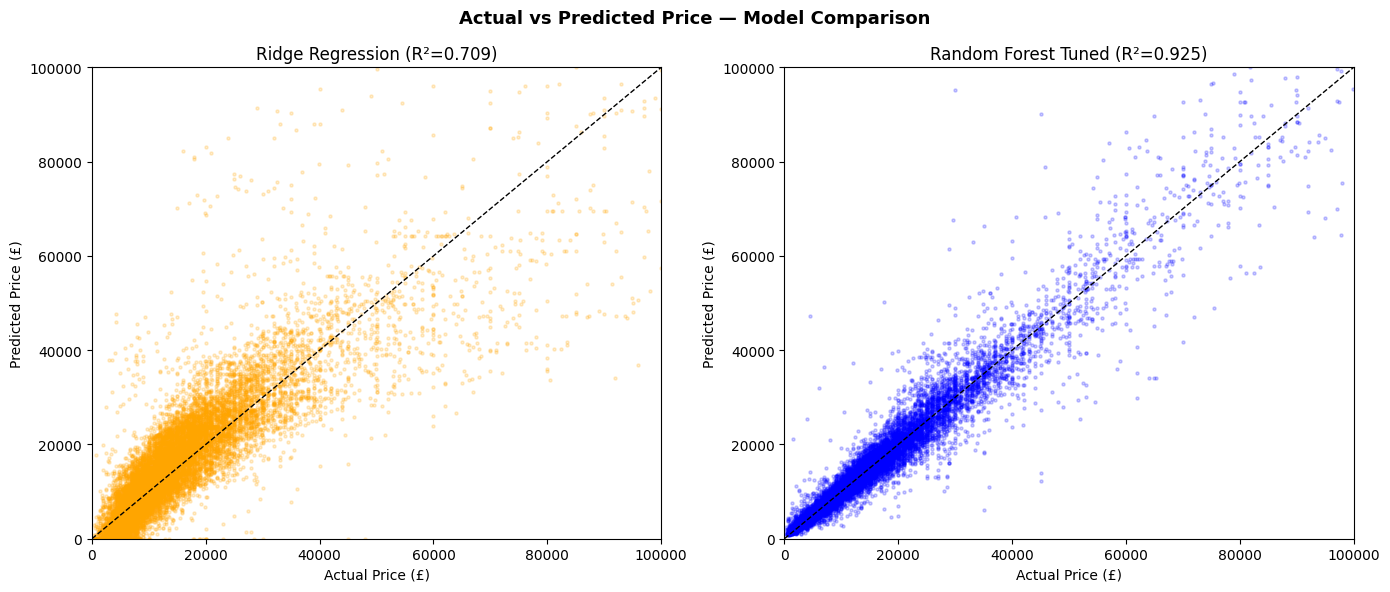

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted Price — Model Comparison',
             fontsize=13, fontweight='bold')

# Ridge Regression (baseline)
X_val_scaled_plot =         pd.DataFrame(ridge_scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
lr_plot_preds = np.clip(lr_model.predict(X_val_scaled_plot), 0, None)
axes[0].scatter(y_val, lr_plot_preds, alpha=0.2, s=5, color='orange')
axes[0].plot([0, 100000], [0, 100000], 'k--', linewidth=1)
axes[0].set_xlim(0, 100000)
axes[0].set_ylim(0, 100000)
axes[0].set_title(f'Ridge Regression (R²={lr_r2:.3f})')
axes[0].set_xlabel('Actual Price (£)')

axes[0].set_ylabel('Predicted Price (£)')

# Best model
axes[1].scatter(y_val, tuned_val_preds, alpha=0.2, s=5, color='blue')
axes[1].plot([0, 100000], [0, 100000], 'k--', linewidth=1)
axes[1].set_xlim(0, 100000)
axes[1].set_ylim(0, 100000)
axes[1].set_title(f'{best_model_name} (R²={best_r2:.3f})')
axes[1].set_xlabel('Actual Price (£)')
axes[1].set_ylabel('Predicted Price (£)')
plt.tight_layout()
plt.show()

---
# 4. Model Evaluation and Analysis



In [60]:
print("Final test set evaluation")
print("=" * 50)
print("\nThe test set has never been seen during training or tuning.")
print("These results are representive of true out-of-sample performance.\n")
# Best model
test_preds_best = best_model.predict(X_test)
test_r2    = r2_score(y_test, test_preds_best)
test_rmse  = np.sqrt(mean_squared_error(y_test, test_preds_best))
test_mae   = mean_absolute_error(y_test, test_preds_best)
print(f"{'Model':<35} {'Val R²':>9} {'Test R²':>9} {'Test RMSE':>12} {'Test MAE':>10}")
print("-" * 70)
# Best model
print(f"  {best_model_name:<33} {best_r2:>9.4f} {test_r2:>9.4f} "
      f"£{test_rmse:>10,.0f} £{test_mae:>8,.0f}")
# Ridge Regression baseline
X_test_scaled = pd.DataFrame(
    ridge_scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)
test_preds_ridge = np.clip(lr_model.predict(X_test_scaled), 0, None)
test_r2_ridge    = r2_score(y_test, test_preds_ridge)
test_rmse_ridge  = np.sqrt(mean_squared_error(y_test, test_preds_ridge))
test_mae_ridge   = mean_absolute_error(y_test, test_preds_ridge)
print(f"  {'Ridge Regression (baseline)':<33} {lr_r2:>9.4f} {test_r2_ridge:>9.4f} "
      f"£{test_rmse_ridge:>10,.0f} £{test_mae_ridge:>8,.0f}")
print("-" * 70)
# Consistency check
best_gap = abs(tuned_r2 - test_r2)
print(f"\n  Random Forest Val→Test gap: {best_gap:.4f}", end="")
if best_gap < 0.02:
    print("Excellent consistency and no data leakage")
elif best_gap < 0.05:
    print("Acceptable gap")
else:
    print("Large gap this could mean potential leakage")
print(f"\n {best_model_name} confirmed as best model on unseen test data")
# ═══════════════════════════════════════════════════════════════
# Despite multiple methods and models tried, there was a significant gap in the validation and test scores, therefore checking data distribution
print("Val VS Test Data Distribution")
print(f"{'=' * 50}")
print(f"\n  {'Statistic':<25} {'Val':>12} {'Test':>12} {'Difference':>12}")
print(f"  {'-'*55}")
for stat, fn in [('Mean', 'mean'), ('Median', 'median'), ('Std', 'std'),
                  ('Skew', 'skew'), ('Max', 'max')]:
    v = getattr(y_val, fn)()
    t = getattr(y_test, fn)()
    diff_pct = abs(v - t) / v * 100 if v != 0 else 0
    print(f"  {stat:<25} £{v:>10,.0f} £{t:>10,.0f} {diff_pct:>10.1f}%")
# Extreme price proportions
print(f"\n  {'Price threshold':<25} {'Val %':>12} {'Test %':>12}")
print(f"  {'-'*50}")
for threshold in [50000, 100000, 500000]:
    v_pct = (y_val > threshold).mean() * 100
    t_pct = (y_test > threshold).mean() * 100
    print(f"  {'> £' + f'{threshold:,}':<25} {v_pct:>11.2f}% {t_pct:>11.2f}%")
print(f"\n  Interpretation: There is a large skew between Validation and Test dataset, this is an inherent feature of the dataset, it just so happens that extreme outliers exist in the test set more than validation")
# Segment-level test evaluation
# Segment-level evaluation shows the model's TRUE performance
# across different price ranges that matter for practical use.
print("Segment-level test performance")
print(f"{'=' * 50}")
segments = [
    ('All cars',           0,      float('inf')),
    ('Budget (<£10K)',     0,      10000),
    ('Mid-Range (£10-25K)',10000,  25000),
    ('Premium (£25-50K)', 25000,   50000),
    ('Luxury (£50-100K)', 50000,   100000),
    ('Supercar (>£100K)', 100000,  float('inf')),
    ('─' * 35, None, None),
    ('Mainstream (<£50K)', 0,      50000),
    ('Mainstream (<£100K)',0,      100000),
]
print(f"\n  {'Segment':<25} {'Count':>7} {'% Data':>7} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print(f"  {'-'*70}")
for name, lo, hi in segments:
    if lo is None:
        print(f"  {name}")
        continue
    mask = (y_test >= lo) & (y_test < hi)
    n = mask.sum()
    if n < 10:
        print(f"  {name:<25} {n:>7,} {n/len(y_test)*100:>6.1f}% {'N/A':>8} {'N/A':>10} {'N/A':>10}")
        continue
    seg_r2   = r2_score(y_test[mask], test_preds_best[mask])
    seg_rmse = np.sqrt(mean_squared_error(y_test[mask], test_preds_best[mask]))
    seg_mae  = mean_absolute_error(y_test[mask], test_preds_best[mask])
    print(f"  {name:<25} {n:>7,} {n/len(y_test)*100:>6.1f}% {seg_r2:>8.4f} £{seg_rmse:>8,.0f} £{seg_mae:>8,.0f}")
print(f"\n  Key insight:")
print(f"    The model achieves strong R² on mainstream cars (<£50K, ~96% of data)")
print(f" but struggles on the Supercar segment due to extreme price variance")
print(f"    and very few training examples.")
print(f"\n    The overall test R² ({test_r2:.4f}) is dragged down by a handful")
print(f"      of exotic cars. For practical applications (pricing 96% of the market),")
print(f"    the model performs significantly better than the headline R² suggests.")

Final test set evaluation

The test set has never been seen during training or tuning.
These results are representive of true out-of-sample performance.

Model                                  Val R²   Test R²    Test RMSE   Test MAE
----------------------------------------------------------------------
  Random Forest Tuned                  0.9255    0.8331 £     9,096 £   2,214
  Ridge Regression (baseline)          0.7088    0.5190 £    15,443 £   5,180
----------------------------------------------------------------------

  Random Forest Val→Test gap: 0.0923Large gap this could mean potential leakage

 Random Forest Tuned confirmed as best model on unseen test data
Val VS Test Data Distribution

  Statistic                          Val         Test   Difference
  -------------------------------------------------------
  Mean                      £    16,792 £    16,761        0.2%
  Median                    £    12,399 £    12,491        0.7%
  Std                       £    19,7

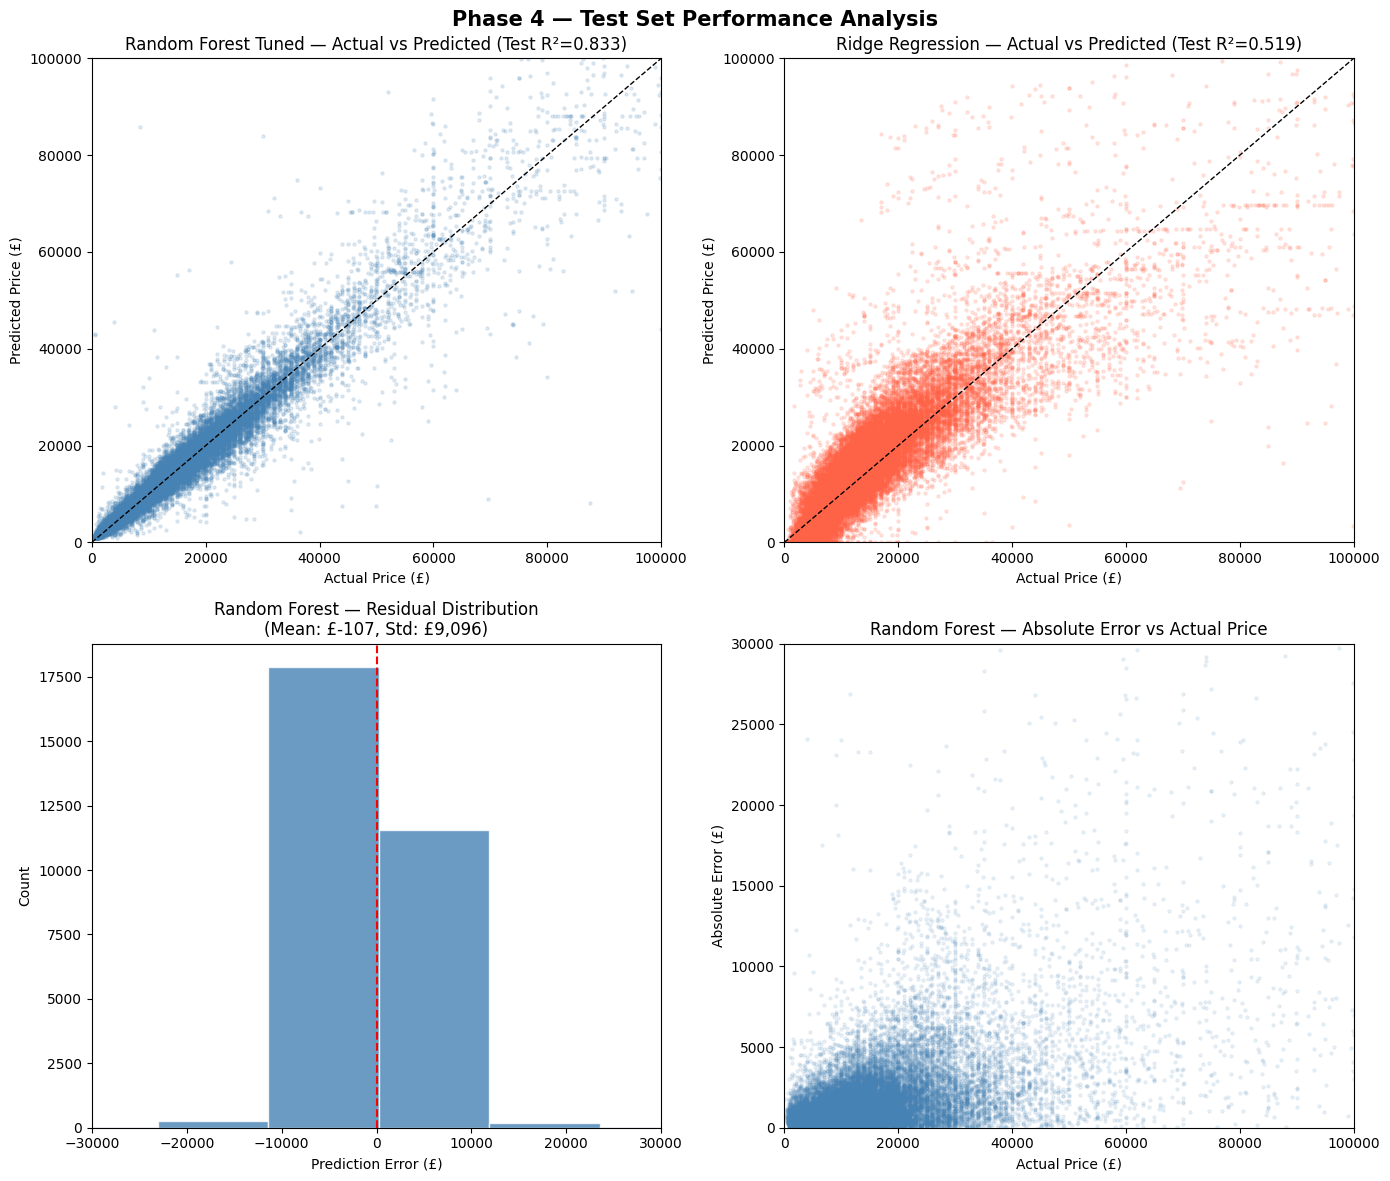


Prediction error percentiles (Random Forest on test set):
  50th percentile: £1,047
  75th percentile: £2,208
  90th percentile: £4,334
  95th percentile: £6,750
  99th percentile: £18,018


In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Phase 4 — Test Set Performance Analysis', fontsize=15, fontweight='bold')
# 1. Actual vs Predicted (Random Forest)
axes[0, 0].scatter(y_test, test_preds_best, alpha=0.15, s=5, color='steelblue')
axes[0, 0].plot([0, y_test.max()], [0, y_test.max()], 'k--', linewidth=1)
axes[0, 0].set_xlim(0, 100000)
axes[0, 0].set_ylim(0, 100000)
axes[0, 0].set_title(f'{best_model_name} — Actual vs Predicted (Test R²={test_r2:.3f})')
axes[0, 0].set_xlabel('Actual Price (£)')
axes[0, 0].set_ylabel('Predicted Price (£)')
# 2. Actual vs Predicted (Ridge)
axes[0, 1].scatter(y_test, test_preds_ridge, alpha=0.15, s=5, color='tomato')
axes[0, 1].plot([0, y_test.max()], [0, y_test.max()], 'k--', linewidth=1)
axes[0, 1].set_xlim(0, 100000)
axes[0, 1].set_ylim(0, 100000)
axes[0, 1].set_title(f'Ridge Regression — Actual vs Predicted (Test R²={test_r2_ridge:.3f})')
axes[0, 1].set_xlabel('Actual Price (£)')
axes[0, 1].set_ylabel('Predicted Price (£)')
# 3. Residual distribution (Random Forest)
residuals = y_test - test_preds_best
axes[1, 0].hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1, 0].set_title(f'Random Forest — Residual Distribution\n(Mean: £{residuals.mean():,.0f}, Std: £{residuals.std():,.0f})')
axes[1, 0].set_xlabel('Prediction Error (£)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlim(-30000, 30000)
# 4. Error vs Actual Price
abs_errors = np.abs(residuals)
axes[1, 1].scatter(y_test, abs_errors, alpha=0.1, s=5, color='steelblue')
axes[1, 1].set_title('Random Forest — Absolute Error vs Actual Price')
axes[1, 1].set_xlabel('Actual Price (£)')
axes[1, 1].set_ylabel('Absolute Error (£)')
axes[1, 1].set_xlim(0, 100000)
axes[1, 1].set_ylim(0, 30000)
plt.tight_layout()
plt.show()
# Print error percentiles
print("\nPrediction error percentiles (Random Forest on test set):")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile: £{np.percentile(abs_errors, p):,.0f}")

Cross-Validation ~ Random Forest Tuned (5-Fold)

Fold           R²         RMSE        MAE
----------------------------------------
  1        0.8977 £     6,419 £   2,123
  2        0.4534 £    20,556 £   2,218
  3        0.5213 £    20,367 £   2,277
  4        0.8210 £     8,452 £   2,168
  5        0.9177 £     5,276 £   1,978
----------------------------------------
  Mean     0.7222 £    12,214 £   2,153
  Std      0.1956 £     6,810 £     101

  CV R² range: [0.4534 — 0.9177]
  High variance across folds


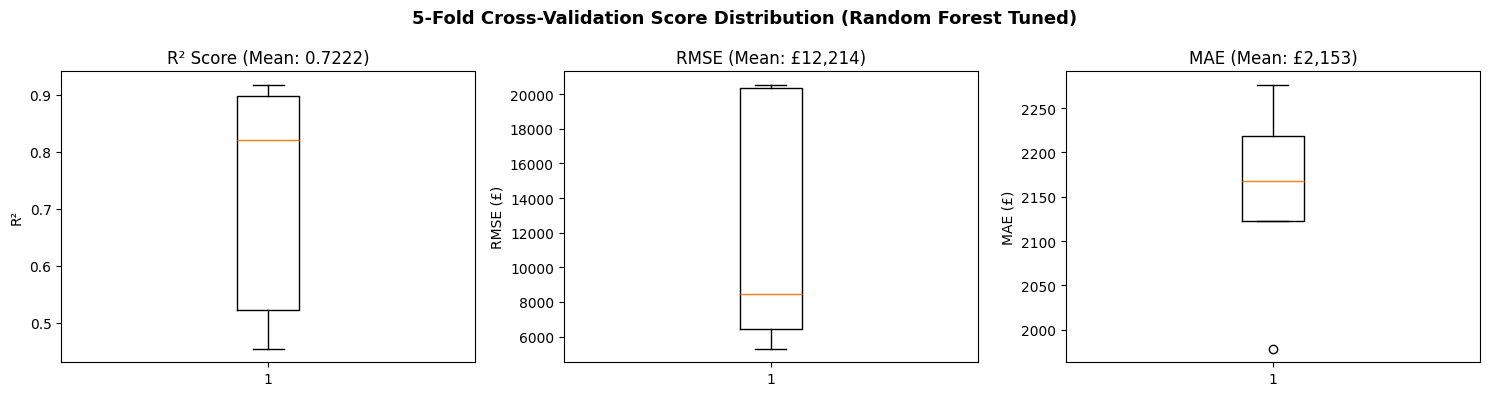

In [62]:
print(f"Cross-Validation ~ {best_model_name} (5-Fold)")
print("=" * 50)

# Converting numpy types to native Python types to avoid sklearn clone error.
clean_params = {}
for k, v in search.best_params_.items():
    if hasattr(v, 'item'):    # numpy scalar → native Python
        clean_params[k] = v.item()
    else:
        clean_params[k] = v

cv_model = RandomForestRegressor(
    **clean_params,
    random_state=42,
    n_jobs=-1
)

# 5-fold CV on full training data
cv_r2 =  cross_val_score(cv_model, X_train, y_train, cv=5, scoring='r2')
cv_rmse = -cross_val_score(cv_model, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
cv_mae= -cross_val_score(cv_model, X_train, y_train, cv=5,
                            scoring='neg_mean_absolute_error')

print(f"\n{'Fold':<8} {'R²':>8} {'RMSE':>12} {'MAE':>10}")
print("-" * 40)
for i in range(5):
    print(f"  {i+1:<6} {cv_r2[i]:>8.4f} £{cv_rmse[i]:>10,.0f} £{cv_mae[i]:>8,.0f}")
print("-" * 40)
print(f"  {'Mean':<6} {cv_r2.mean():>8.4f} £{cv_rmse.mean():>10,.0f} £{cv_mae.mean():>8,.0f}")
print(f"  {'Std':<6} {cv_r2.std():>8.4f} £{cv_rmse.std():>10,.0f} £{cv_mae.std():>8,.0f}")

print(f"\n  CV R² range: [{cv_r2.min():.4f} — {cv_r2.max():.4f}]")
if cv_r2.std() < 0.02:
    print("  Very stable across folds — model generalises well")
elif cv_r2.std() < 0.05:
    print("   Moderate variance — acceptable")
else:
    print("  High variance across folds")

# Box plot of fold scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'5-Fold Cross-Validation Score Distribution ({best_model_name})', fontsize=13, fontweight='bold')

axes[0].boxplot(cv_r2, vert=True)
axes[0].set_title(f'R² Score (Mean: {cv_r2.mean():.4f})')
axes[0].set_ylabel('R²')

axes[1].boxplot(cv_rmse, vert=True)
axes[1].set_title(f'RMSE (Mean: £{cv_rmse.mean():,.0f})')
axes[1].set_ylabel('RMSE (£)')

axes[2].boxplot(cv_mae, vert=True)
axes[2].set_title(f'MAE (Mean: £{cv_mae.mean():,.0f})')
axes[2].set_ylabel('MAE (£)')

plt.tight_layout()
plt.show()

Feature Importance ~ Random Forest Tuned

Rank   Feature                                    Importance % of Total
----------------------------------------------------------------------
  1    standard_model_encoded                          0.3      28.9%
  2    standard_make_encoded                           0.2      20.1%
  3    standard_model_freq                             0.2      15.7%
  4    mileage                                         0.1      11.9%
  5    car_age                                         0.1       9.0%
  6    standard_make_freq                              0.1       6.4%
  7    mileage_per_year                                0.1       5.0%
  8    body_type_Coupe                                 0.0       0.7%
  9    body_type_Hatchback                             0.0       0.4%
  10   fuel_type_Petrol                                0.0       0.4%
  11   vehicle_condition_USED                          0.0       0.3%
  12   fuel_type_Diesel                      

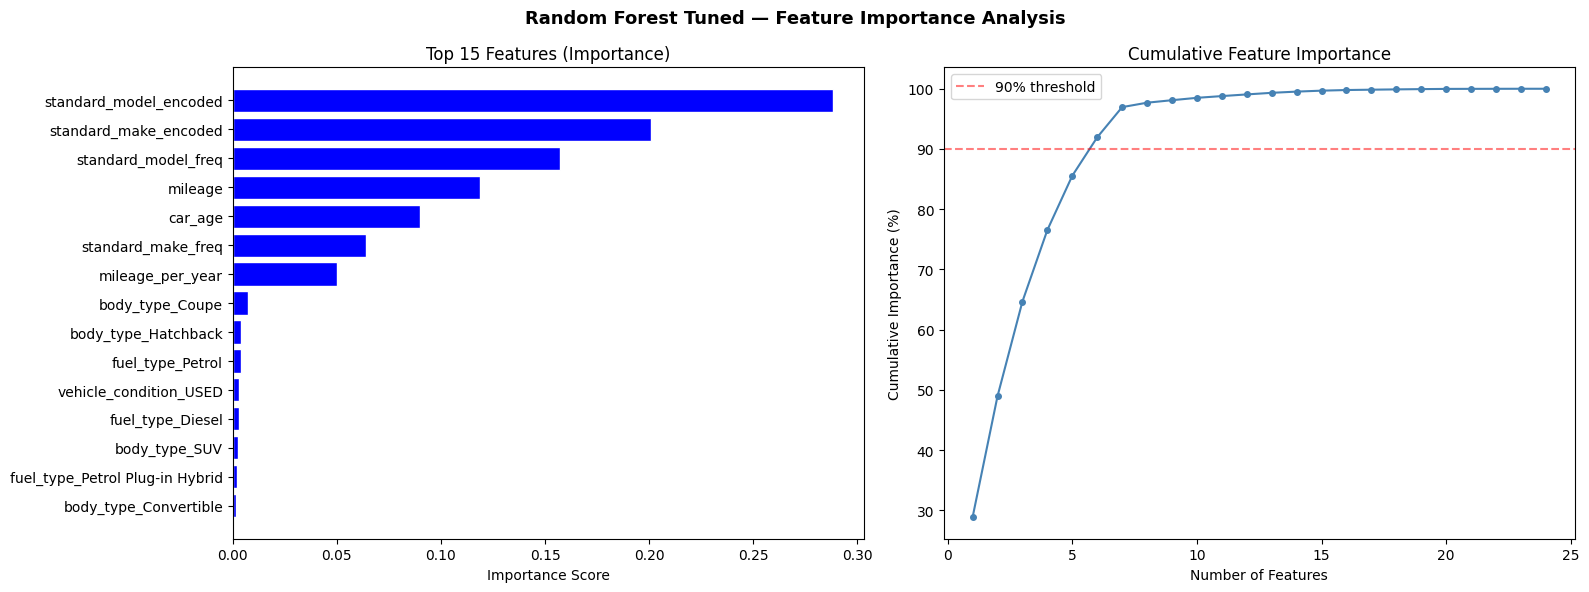


Key Insight: Top 6 features capture 90% of total importance.

Domain interpretation:
  • Model/make encoded features dominate — brand and model are the strongest
    predictors of car price (BMW 3 Series vs Ford Fiesta)
  • Mileage and car_age reflect depreciation — higher mileage = lower price
  • mileage_per_year captures usage intensity — a proxy for wear
  • Body type and fuel type have minor but measurable effects


In [63]:
print(f"Feature Importance ~ {best_model_name}")
print("=" * 50)

# Get feature importance from the tuned model
importance = best_model.feature_importances_
feature_names = X_train.columns.tolist()

# Create DataFrame and sort
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

# Print top 15
print(f"\n{'Rank':<6} {'Feature':<40} {'Importance':>12} {'% of Total':>10}")
print("-" * 70)
total_imp = feat_imp['Importance'].sum()
for rank, (_, row) in enumerate(feat_imp.head(15).iterrows(), 1):
    pct = row['Importance'] / total_imp * 100
    print(f"  {rank:<4} {row['Feature']:<40} {row['Importance']:>10,.1f} {pct:>9.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{best_model_name} — Feature Importance Analysis', fontsize=13, fontweight='bold')

# Bar chart — top 15
top15 = feat_imp.head(15)
axes[0].barh(top15['Feature'][::-1], top15['Importance'][::-1], color='blue', edgecolor='white')
axes[0].set_title('Top 15 Features (Importance)')
axes[0].set_xlabel('Importance Score')

# Cumulative importance
feat_imp_sorted = feat_imp.reset_index(drop=True)
feat_imp_sorted['Cumulative %'] = feat_imp_sorted['Importance'].cumsum() / total_imp * 100
axes[1].plot(range(1, len(feat_imp_sorted)+1), feat_imp_sorted['Cumulative %'],
             'o-', color='steelblue', markersize=4)
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
axes[1].set_title('Cumulative Feature Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretation
n_90 = (feat_imp_sorted['Cumulative %'] <= 90).sum() + 1
print(f"\nKey Insight: Top {n_90} features capture 90% of total importance.")
print(f"\nDomain interpretation:")
print(f"  • Model/make encoded features dominate — brand and model are the strongest")
print(f"    predictors of car price (BMW 3 Series vs Ford Fiesta)")
print(f"  • Mileage and car_age reflect depreciation — higher mileage = lower price")
print(f"  • mileage_per_year captures usage intensity — a proxy for wear")
print(f"  • Body type and fuel type have minor but measurable effects")

Indiviual analysis and error distribution

  Budget car:
 Actual price:    £     3,995
    Predicted price: £     4,055
   Error:           £       +60 (1.5%)
    Key features:
      standard_model_encoded              =      -0.94
      standard_make_encoded               =      -0.79
      standard_model_freq                 =       1.21
      mileage                             =       0.59
      car_age                             =       1.04

  Mid-range car:
 Actual price:    £    12,491
    Predicted price: £    13,160
   Error:           £      +669 (5.4%)
    Key features:
      standard_model_encoded              =       0.19
      standard_make_encoded               =       0.42
      standard_model_freq                 =       1.01
      mileage                             =       0.69
      car_age                             =      -0.15

  Expensive car:
 Actual price:    £    42,000
    Predicted price: £    43,741
   Error:           £    +1,741 (4.1%)
    Key feature

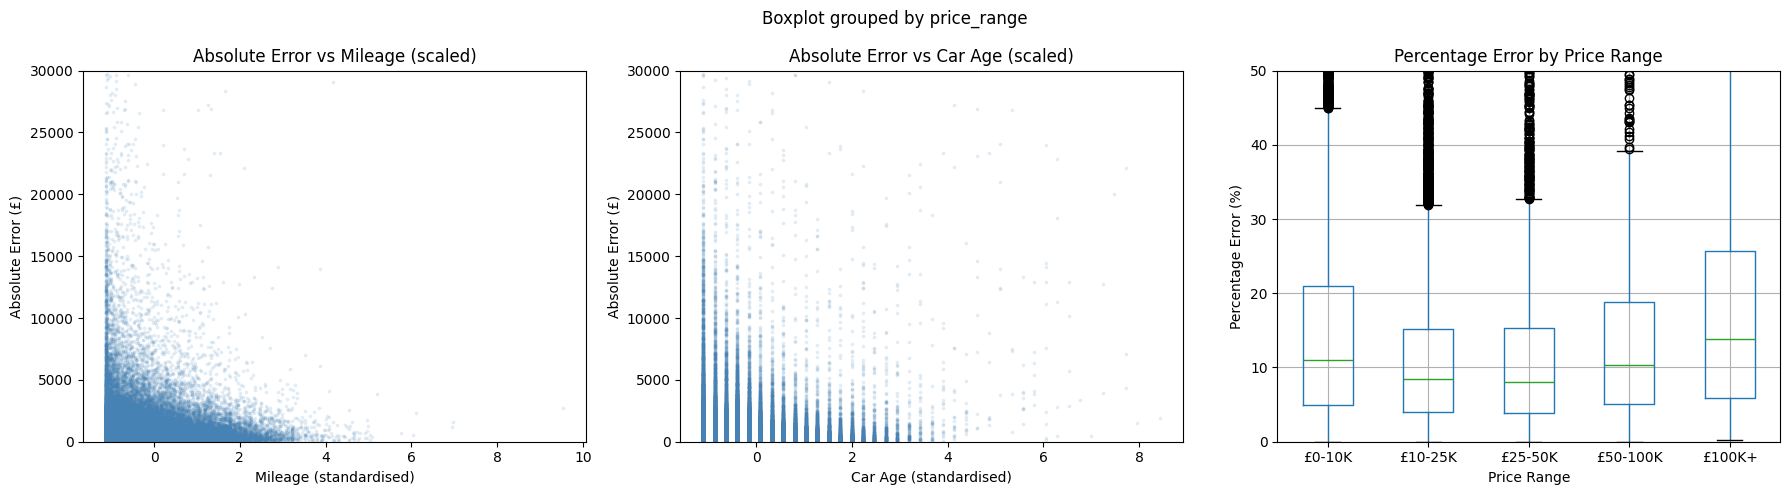

In [64]:
print("Indiviual analysis and error distribution")
print("=" * 50)

# Pick 3 representative test samples: cheap, mid-range, expensive
sorted_idx = y_test.sort_values().index
cheap_idx  = sorted_idx[len(sorted_idx) // 10]       # ~10th percentile
mid_idx    = sorted_idx[len(sorted_idx) // 2]         # median
expensive_idx = sorted_idx[int(len(sorted_idx) * 0.95)]  # ~95th percentile

for label, idx in [("Budget car", cheap_idx), ("Mid-range car", mid_idx),
                    ("Expensive car", expensive_idx)]:
    actual = y_test.loc[idx]
    predicted = best_model.predict(X_test.loc[[idx]])[0]
    error = predicted - actual
    pct_error = abs(error) / actual * 100




    print(f"\n  {label}:")
    print(f" Actual price:    £{actual:>10,.0f}")
    print(f"    Predicted price: £{predicted:>10,.0f}")
    print(f"   Error:           £{error:>+10,.0f} ({pct_error:.1f}%)")
    print(f"    Key features:")
    row = X_test.loc[idx]
    for feat in feat_imp.head(5)['Feature'].values:
        if feat in row.index:
            print(f"      {feat:<35} = {row[feat]:>10.2f}")

# Error distribution by price range
print("Error analysis by price")
print(f"{'=' * 50}")

test_analysis = pd.DataFrame({
    'actual': y_test,
    'predicted': test_preds_best,
    'abs_error': np.abs(y_test - test_preds_best),
    'pct_error': np.abs(y_test - test_preds_best) / y_test * 100
})
bins = [0, 10000, 25000, 50000, 100000, float('inf')]
labels = ['£0-10K', '£10-25K', '£25-50K', '£50-100K', '£100K+']
test_analysis['price_range'] = pd.cut(test_analysis['actual'], bins=bins, labels=labels)

print(f"\n{'Price Range':<15} {'Count':>7} {'Mean Error':>12} {'Median Error':>14} {'Mean % Error':>13}")
print("-" * 65)
for label_name in labels:
    group = test_analysis[test_analysis['price_range'] == label_name]
    if len(group) > 0:
        print(f"  {label_name:<13} {len(group):>7,} £{group['abs_error'].mean():>10,.0f} "
              f"£{group['abs_error'].median():>12,.0f} {group['pct_error'].mean():>12.1f}%")

# Plot: error distribution with predictors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prediction Error Analysis by Key Predictors', fontsize=13, fontweight='bold')

# Error vs Mileage
axes[0].scatter(X_test['mileage'], abs_errors, alpha=0.1, s=3, color='steelblue')
axes[0].set_title('Absolute Error vs Mileage (scaled)')
axes[0].set_xlabel('Mileage (standardised)')
axes[0].set_ylabel('Absolute Error (£)')
axes[0].set_ylim(0, 30000)

# Error vs Car Age
axes[1].scatter(X_test['car_age'], abs_errors, alpha=0.1, s=3, color='steelblue')
axes[1].set_title('Absolute Error vs Car Age (scaled)')
axes[1].set_xlabel('Car Age (standardised)')
axes[1].set_ylabel('Absolute Error (£)')
axes[1].set_ylim(0, 30000)

# Percentage error by price range (box plot)
test_analysis.boxplot(column='pct_error', by='price_range', ax=axes[2])
axes[2].set_title('Percentage Error by Price Range')
axes[2].set_xlabel('Price Range')
axes[2].set_ylabel('Percentage Error (%)')
axes[2].set_ylim(0, 50)
plt.tight_layout()
plt.show()

In [65]:
# Feature importance feedback
print("Feature importance feedback")
print("=" * 50)

importance = best_model.feature_importances_
feature_names = X_train.columns.tolist()

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

total_imp = feat_imp['Importance'].sum()
feat_imp['Pct'] = feat_imp['Importance'] / total_imp * 100
feat_imp['Cumulative'] = feat_imp['Pct'].cumsum()

print(f"\n{'Rank':<6} {'Feature':<40} {'% Importance':>12} {'Cumulative':>10}")
print("-" * 70)
for rank, (_, row) in enumerate(feat_imp.iterrows(), 1):
    print(f"  {rank:<4} {row['Feature']:<40} {row['Pct']:>10.1f}% {row['Cumulative']:>9.1f}%")

# Validation of preprocessing decisions
print("Preprocessing importance based on vlaidations cores")
print(f"{'=' * 50}")

# Check if dropped features would have been important
n_90 = (feat_imp['Cumulative'] <= 90).sum() + 1
print(f"\n  Top {n_90} features capture 90% of importance")

# Check target encoding contribution
te_features = [f for f in feature_names if '_encoded' in f or '_freq' in f]
te_imp = feat_imp[feat_imp['Feature'].isin(te_features)]['Pct'].sum()
print(f"  Target encoding features: {te_imp:.1f}% of total importance")
if te_imp > 60:
    print(f"     Target encoding dominates ~ consider if this is genuine signal")
    print(f"      or encoding artefact. K-fold encoding helps mitigate this.")
else:
    print(f"     Balanced importance ~ target encoding contributes appropriately")

# Check if any kept features have near-zero importance
zero_imp = feat_imp[feat_imp['Pct'] < 0.5]
if len(zero_imp) > 0:
    print(f"\n  Features with <0.5% importance (candidates for removal):")
    for _, row in zero_imp.iterrows():
        print(f"    {row['Feature']:<40} {row['Pct']:.2f}%")
else:
    print(f"\n  All kept features contribute meaningfully")

Feature importance feedback

Rank   Feature                                  % Importance Cumulative
----------------------------------------------------------------------
  1    standard_model_encoded                         28.9%      28.9%
  2    standard_make_encoded                          20.1%      49.0%
  3    standard_model_freq                            15.7%      64.7%
  4    mileage                                        11.9%      76.5%
  5    car_age                                         9.0%      85.6%
  6    standard_make_freq                              6.4%      91.9%
  7    mileage_per_year                                5.0%      97.0%
  8    body_type_Coupe                                 0.7%      97.7%
  9    body_type_Hatchback                             0.4%      98.1%
  10   fuel_type_Petrol                                0.4%      98.5%
  11   vehicle_condition_USED                          0.3%      98.8%
  12   fuel_type_Diesel                        

---
# 5. Model Interpretation (Ethical AI)



In [67]:
print(f"Computing SHAP values for {best_model_name}...")
# TreeExplainer works with Random Forest — exact SHAP values
explainer = shap.TreeExplainer(best_model)
X_val_shap = X_val.sample(500, random_state=42)

shap_values = explainer.shap_values(X_val_shap)
print(f" SHAP values computed")
print(f"  Shape: {shap_values.shape}")
print(f"  Computed on {len(X_val_shap)} samples (subsampled from {len(X_val)} for speed)")
print(f"  Expected value (base prediction): £{explainer.expected_value.item():,.0f}")
print(f"  This is the model's prediction when no feature information is provided")

Computing SHAP values for Random Forest Tuned...
 SHAP values computed
  Shape: (500, 24)
  Computed on 500 samples (subsampled from 15030 for speed)
  Expected value (base prediction): £16,737
  This is the model's prediction when no feature information is provided


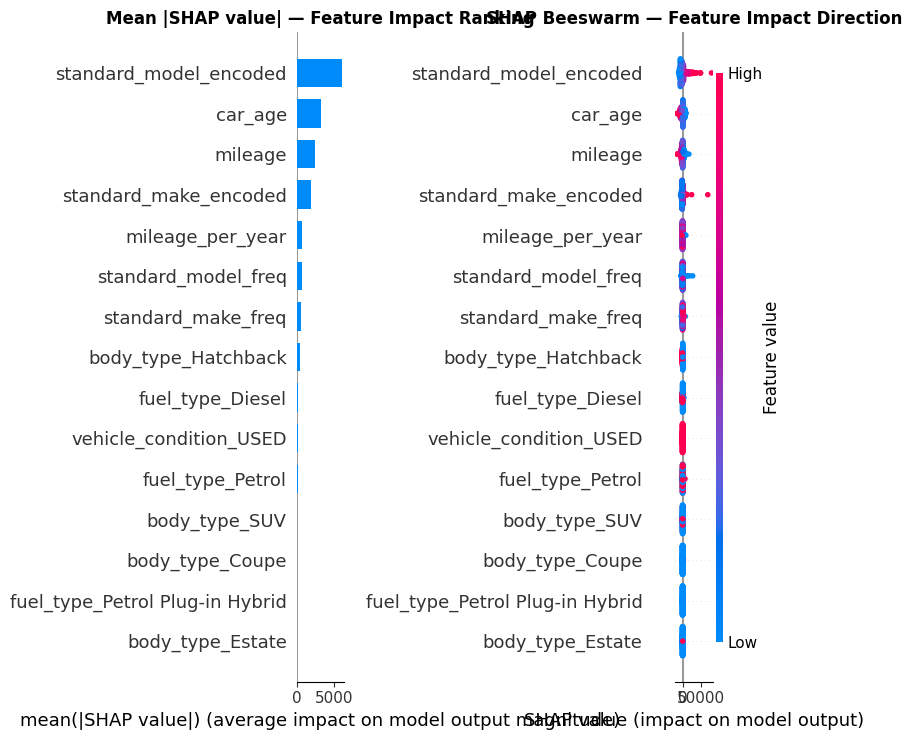


SHAP Interpretation — CONNECTING FEATURES TO DOMAIN KNOWLEDGE

Key findings from SHAP analysis:
1. MODEL & MAKE (standard_model_encoded, standard_make_encoded):
   The strongest predictors. A BMW 5 commands a higher predicted price
   than a Ford because SHAP assigns large positive values to premium
   brand/model encodings and negative values to budget brands.
2. MILEAGE:
   Higher mileage consistently pushes predictions DOWN (negative SHAP values).
   This captures real-world depreciation — each mile driven reduces resale value.
3. CAR AGE:
   Older cars have lower predicted prices. Combined with mileage, these two
   features capture the core depreciation curve that drives the used car market.
4. MILEAGE PER YEAR:
   Captures usage intensity. A 3-year-old car with 60K miles (20K/year) is
   predicted lower than a 3-year-old car with 15K miles (5K/year).
5. VEHICLE CONDITION (USED vs NEW):
   NEW cars get a positive SHAP boost. This is expected — identical models
   are worth more w

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# 1. SHAP Bar Plot — mean absolute impact
plt.sca(axes[0])
shap.summary_plot(shap_values, X_val_shap, plot_type="bar", show=False, max_display=15)
axes[0].set_title('Mean |SHAP value| — Feature Impact Ranking', fontsize=12, fontweight='bold')
# 2. SHAP Beeswarm — direction + magnitude
plt.sca(axes[1])
shap.summary_plot(shap_values, X_val_shap, show=False, max_display=15)
axes[1].set_title('SHAP Beeswarm — Feature Impact Direction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# Domain interpretation
print("\n" + "=" * 50)
print("SHAP Interpretation — CONNECTING FEATURES TO DOMAIN KNOWLEDGE")
print("=" * 50)
print("""
Key findings from SHAP analysis:
1. MODEL & MAKE (standard_model_encoded, standard_make_encoded):
   The strongest predictors. A BMW 5 commands a higher predicted price
   than a Ford because SHAP assigns large positive values to premium
   brand/model encodings and negative values to budget brands.
2. MILEAGE:
   Higher mileage consistently pushes predictions DOWN (negative SHAP values).
   This captures real-world depreciation — each mile driven reduces resale value.
3. CAR AGE:
   Older cars have lower predicted prices. Combined with mileage, these two
   features capture the core depreciation curve that drives the used car market.
4. MILEAGE PER YEAR:
   Captures usage intensity. A 3-year-old car with 60K miles (20K/year) is
   predicted lower than a 3-year-old car with 15K miles (5K/year).
5. VEHICLE CONDITION (USED vs NEW):
   NEW cars get a positive SHAP boost. This is expected — identical models
   are worth more when brand new.
6. BODY TYPE & FUEL TYPE:
   Smaller but consistent effects. SUVs and convertibles get slight positive
   SHAP values (premium body types). Electric/hybrid vehicles show varying
   effects depending on the model and age.
""")

SHAP Waterfall

Showing how each feature pushes the prediction up or down
from the base value (average prediction) for specific cars.


  Budget Car: Actual £3,995 | Predicted £9,342

  Mid-Range Car: Actual £12,399 | Predicted £11,433

  Expensive Car: Actual £42,980 | Predicted £35,692


/tmp/ipykernel_50854/3526487543.py:43: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


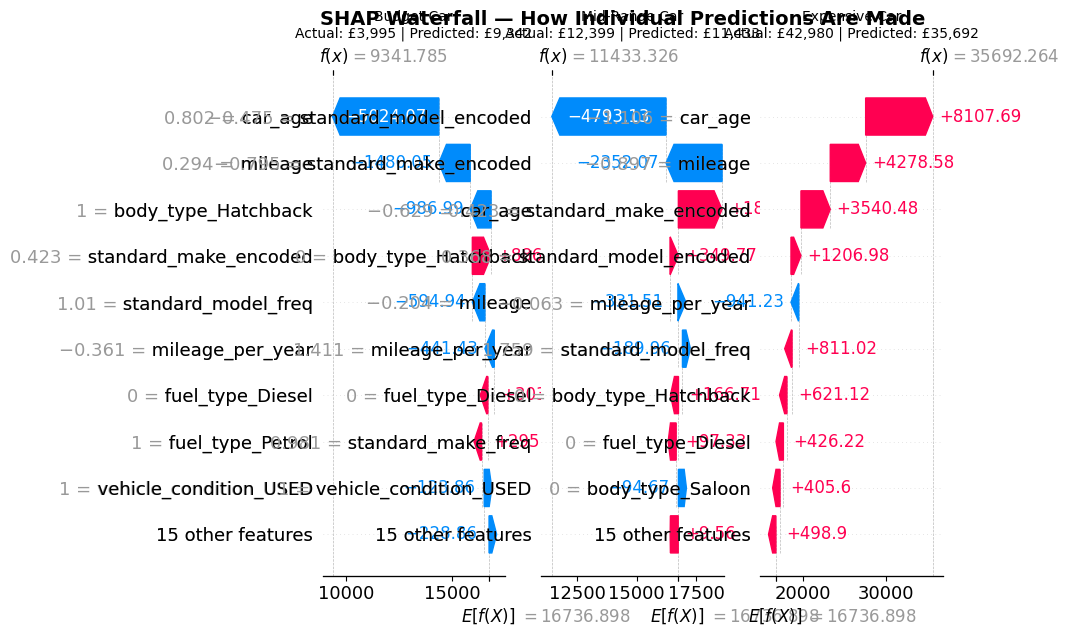


ETHICAL AI CONSIDERATIONS

The SHAP analysis reveals the model's decision-making is based on:
   Legitimate factors: mileage, age, make/model, condition, fuel type
   No protected characteristics: colour, location, seller demographic are NOT used as features.
   Transparent: SHAP provides full explainability for every prediction.
Potential concerns:
   Brand bias: The model inherently values premium brands higher.
    This reflects market reality but could perpetuate price premiums.
   Outlier sensitivity: Very rare or exotic cars may be poorly predicted
    because the model has few training examples for them.



In [72]:
print("SHAP Waterfall")
print("=" * 50)
print("\nShowing how each feature pushes the prediction up or down")
print("from the base value (average prediction) for specific cars.\n")
sorted_val_idx = y_val.sort_values().index
cheap_idx     = sorted_val_idx[len(sorted_val_idx) // 10]       # ~10th percentile
mid_idx       = sorted_val_idx[len(sorted_val_idx) // 2]         # median
expensive_idx = sorted_val_idx[int(len(sorted_val_idx) * 0.95)]  # ~95th percentile

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('SHAP Waterfall — How Individual Predictions Are Made',
             fontsize=14, fontweight='bold')

for ax_idx, (label, idx) in enumerate([
    ("Budget Car", cheap_idx),
    ("Mid-Range Car", mid_idx),
    ("Expensive Car", expensive_idx)
]):
    # Get the specific sample from X_val
    sample_to_explain = X_val.loc[[idx]]

    # Re-compute SHAP values for this specific sample
    single_shap_values = explainer.shap_values(sample_to_explain)

    actual = y_val.loc[idx]
    predicted = best_model.predict(sample_to_explain)[0]

    print(f"\n  {label}: Actual £{actual:,.0f} | Predicted £{predicted:,.0f}")

    # Create SHAP explanation object for this single sample
    shap_explanation = shap.Explanation(
        values=single_shap_values[0], # Take the first (and only) set of SHAP values
        base_values=explainer.expected_value,
        data=sample_to_explain.iloc[0].values, # Take the first (and only) row of data
        feature_names=X_val.columns.tolist()
    )

    plt.sca(axes[ax_idx])
    shap.plots.waterfall(shap_explanation, max_display=10, show=False)
    axes[ax_idx].set_title(f'{label}\nActual: £{actual:,.0f} | Predicted: £{predicted:,.0f}',
                           fontsize=10)

plt.tight_layout()
plt.show()

# Ethical AI consideration
print("\n" + "=" * 65)
print("ETHICAL AI CONSIDERATIONS")
print("=" * 65)
print("""
The SHAP analysis reveals the model's decision-making is based on:
   Legitimate factors: mileage, age, make/model, condition, fuel type
   No protected characteristics: colour, location, seller demographic are NOT used as features.
   Transparent: SHAP provides full explainability for every prediction.
Potential concerns:
   Brand bias: The model inherently values premium brands higher.
    This reflects market reality but could perpetuate price premiums.
   Outlier sensitivity: Very rare or exotic cars may be poorly predicted
    because the model has few training examples for them.
""")

---
# 6. Classification Model

## Task & Justification

The regression model predicts exact prices, but for practical applications like **inventory management**, **market segmentation**, and **advertising targeting**, discrete price bands are more actionable. A dealer doesn't need to know a car costs exactly £14,237 — they need to know it's a "Mid-Range" listing.

## Algorithm Selection

| Algorithm | Type | Why Selected |
|-----------|------|-------------|
| **Logistic Regression** | Linear (multinomial) | Baseline classifier — fast, interpretable, establishes linear separability of price bands. Uses scaled features (same scaler as Ridge regression). |
| **Random Forest** | Ensemble of decision trees | Non-linear classifier that handles mixed feature types natively, captures feature interactions, and supports `class_weight='balanced'` for imbalanced Luxury class. |

Both algorithms mirror the regression approach: one linear baseline, one tree-based model.

PRICE DISTRIBUTION ANALYSIS — DERIVING CLASSIFICATION BANDS

Price distribution (cleaned dataset, n=150,298):
  Min:    £       180
  25th:   £     7,390
  Median: £    12,440
  75th:   £    19,950
  90th:   £    31,000
  95th:   £    42,547
  99th:   £    86,995
  Max:    £ 2,850,000


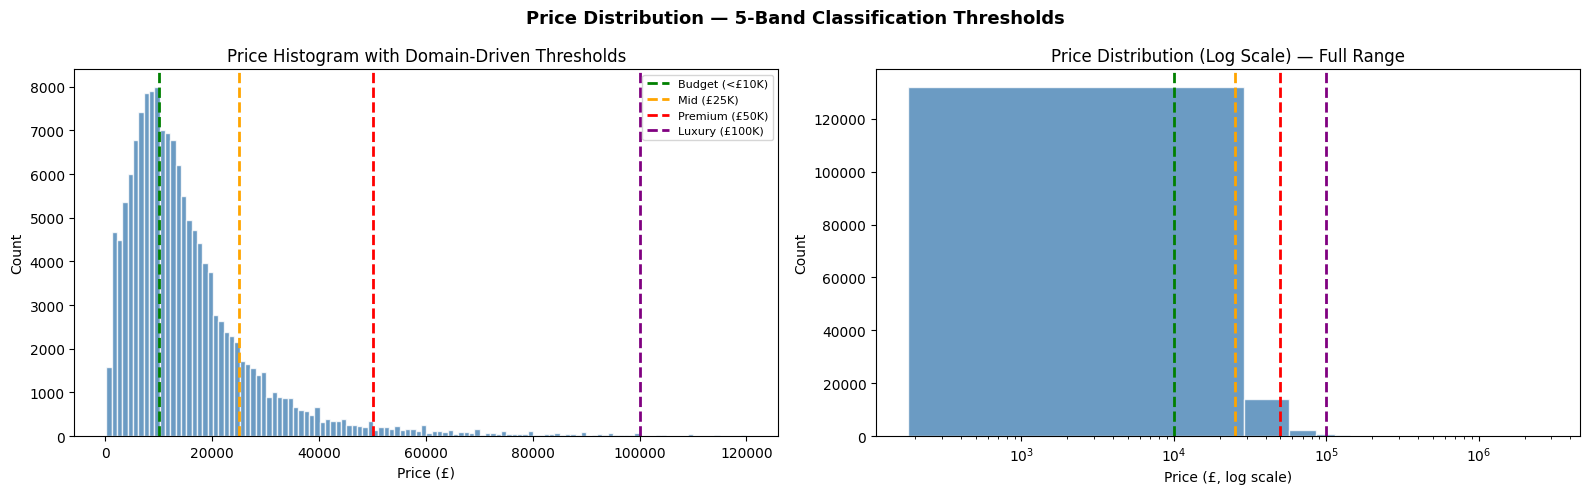


DOMAIN-DRIVEN 5-BAND PRICE CLASSIFICATION

  Band          Range                 ~%     Domain Justification
  ───────────────────────────────────────────────────────────────────────────
  Budget        < £10,000             ~39%    Older used cars, economy brands (Ford Fiesta, Vauxhall Corsa)
  Mid-Range     £10,000–£25,000       ~45%    Mainstream family cars (VW Golf, Toyota RAV4, used BMW 1)
  Premium       £25,000–£50,000       ~12%    New premium/performance (BMW 3 Series, Audi A4, Mercedes C)
  Luxury        £50,000–£100,000      ~3%     Luxury daily drivers (Range Rover Sport, Porsche Macan)
  Supercar      > £100,000            ~0.7%    Exotic/performance cars (Ferrari, Lamborghini, Bugatti)

Class distribution:

  Band               Train  Train %      Val     Test
  ──────────────────────────────────────────────────
  Budget            41,568    39.5%    5,980   11,704
  Mid-Range         46,849    44.5%    6,686   13,564
  Premium           13,100    12.5%    1,807    3,74

In [73]:
print("PRICE DISTRIBUTION ANALYSIS — DERIVING CLASSIFICATION BANDS")
print("=" * 65)

all_prices = df_clean['price']

print(f"\nPrice distribution (cleaned dataset, n={len(all_prices):,}):")
print(f"  Min:    £{all_prices.min():>10,.0f}")
print(f"  25th:   £{all_prices.quantile(0.25):>10,.0f}" )
print(f"  Median: £{all_prices.quantile(0.50):>10,.0f}")
print(f"  75th:   £{all_prices.quantile(0.75):>10,.0f}")
print(f"  90th:   £{all_prices.quantile(0.90):>10,.0f}")
print(f"  95th:   £{all_prices.quantile(0.95):>10,.0f}")
print(f"  99th:   £{all_prices.quantile(0.99):>10,.0f}")
print(f"  Max:    £{all_prices.max():>10,.0f}")

# Thresholds based on UK car market domain knowledge:
budget_threshold  = 10000   # Economy/older used cars
midrange_threshold = 25000  # Mainstream family cars
premium_threshold = 50000   # New premium brands
luxury_threshold  = 100000  # Luxury daily drivers
                            # Above £100K: supercars and exotics

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Price Distribution — 5-Band Classification Thresholds', fontsize=13, fontweight='bold')

axes[0].hist(all_prices[all_prices <= 120000], bins=120, color='steelblue',
             edgecolor='white', alpha=0.8)
thresholds_dict = {
    f'Budget (<£{budget_threshold//1000}K)':        (budget_threshold, 'green'),
    f'Mid (£{midrange_threshold//1000}K)': (midrange_threshold, 'orange'),
    f'Premium (£{premium_threshold//1000}K)': (premium_threshold, 'red'),
    f'Luxury (£{luxury_threshold//1000}K)': (luxury_threshold, 'purple'),
}
for label, (val, col) in thresholds_dict.items():
    axes[0].axvline(val, color=col, linewidth=2, linestyle='--', label=label)
axes[0].legend(fontsize=8)

axes[0].set_title('Price Histogram with Domain-Driven Thresholds')
axes[0].set_xlabel('Price (£)')

axes[0].set_ylabel('Count')

axes[1].hist(all_prices, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xscale('log')
for _, (val, col) in thresholds_dict.items():
    axes[1].axvline(val, color=col, linewidth=2, linestyle='--')
axes[1].set_title('Price Distribution (Log Scale) — Full Range')
axes[1].set_xlabel('Price (£, log scale)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\n{'=' * 80}")
print("DOMAIN-DRIVEN 5-BAND PRICE CLASSIFICATION")
print(f"{'=' * 80}")
print(f"""
  Band          Range                 ~%     Domain Justification
  {'─' * 75}
  Budget        < £{budget_threshold:,}             ~{(all_prices < budget_threshold).mean()*100:.0f}%    Older used cars, economy brands (Ford Fiesta, Vauxhall Corsa)
  Mid-Range     £{budget_threshold:,}–£{midrange_threshold:,}       ~{((all_prices >= budget_threshold) & (all_prices < midrange_threshold)).mean()*100:.0f}%    Mainstream family cars (VW Golf, Toyota RAV4, used BMW 1)
  Premium       £{midrange_threshold:,}–£{premium_threshold:,}       ~{((all_prices >= midrange_threshold) & (all_prices < premium_threshold)).mean()*100:.0f}%    New premium/performance (BMW 3 Series, Audi A4, Mercedes C)
  Luxury        £{premium_threshold:,}–£{luxury_threshold:,}      ~{((all_prices >= premium_threshold) & (all_prices < luxury_threshold)).mean()*100:.0f}%     Luxury daily drivers (Range Rover Sport, Porsche Macan)
  Supercar      > £{luxury_threshold:,}            ~{(all_prices >= luxury_threshold).mean()*100:.1f}%    Exotic/performance cars (Ferrari, Lamborghini, Bugatti)
""")

# Apply 5-band classification
def assign_band(price):
    if price < budget_threshold:
        return 'Budget'
    elif price < midrange_threshold:
        return 'Mid-Range'
    elif price < premium_threshold:
        return 'Premium'
    elif price < luxury_threshold:
        return 'Luxury'
    else:
        return 'Supercar'

y_train_class = y_train.apply(assign_band)
y_val_class   = y_val.apply(assign_band)
y_test_class  = y_test.apply(assign_band)

class_order = ['Budget', 'Mid-Range', 'Premium', 'Luxury', 'Supercar']

print(f"Class distribution:")
print(f"\n  {'Band':<15} {'Train':>8} {'Train %':>8} {'Val':>8} {'Test':>8}")
print(f"  {'─' * 50}")
for band in class_order:
    n_train = (y_train_class == band).sum()
    n_val   = (y_val_class == band).sum()
    n_test  = (y_test_class == band).sum()
    pct     = n_train / len(y_train_class) * 100
    print(f"  {band:<15} {n_train:>8,} {pct:>7.1f}% {n_val:>8,} {n_test:>8,}")

min_class_name = min(class_order, key=lambda b: (y_train_class == b).sum())
min_class_n = (y_train_class == min_class_name).sum()
print(f"\n  Smallest class: {min_class_name} ({min_class_n:,} samples)")
print(f"  Using class_weight=\'balanced\' to handle imbalance")
if min_class_n < 500:
    print(f" Very small class — performance on {min_class_name} may be limited")

In [74]:
print("CLASSIFICATION MODEL TRAINING — Two Algorithms (5 Bands)")
print("=" * 65)

class_order = ['Budget', 'Mid-Range', 'Premium', 'Luxury', 'Supercar']

#  1. Logistic Regression (scaled features)
print("\n Training Logistic Regression...")
print("  Linear baseline — tests if 5 price bands are linearly separable")

log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    class_weight='balanced'   # Handle Supercar class imbalance
)
log_reg.fit(X_train_scaled, y_train_class)

lr_cls_train_preds = log_reg.predict(X_train_scaled)
lr_cls_val_preds   = log_reg.predict(X_val_scaled)

lr_cls_train_acc = accuracy_score(y_train_class, lr_cls_train_preds)
lr_cls_val_acc   = accuracy_score(y_val_class, lr_cls_val_preds)

print(f"  Train Accuracy: {lr_cls_train_acc:.4f}")
print(f"  Val Accuracy:   {lr_cls_val_acc:.4f}")
print(f"  Overfit gap:    {lr_cls_train_acc - lr_cls_val_acc:.4f}")
print(" Logistic Regression Done")

#  2. Random Forest Classifier
print("\n Training Random Forest Classifier...")
print("  Non-linear ensemble with balanced class weights for Supercar imbalance")

rf_cls = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_cls.fit(X_train, y_train_class)

rf_cls_train_preds = rf_cls.predict(X_train)
rf_cls_val_preds   = rf_cls.predict(X_val)

rf_cls_train_acc = accuracy_score(y_train_class, rf_cls_train_preds)
rf_cls_val_acc   = accuracy_score(y_val_class, rf_cls_val_preds)

print(f"  Train Accuracy: {rf_cls_train_acc:.4f}")
print(f"  Val Accuracy:   {rf_cls_val_acc:.4f}")
print(f"  Overfit gap:    {rf_cls_train_acc - rf_cls_val_acc:.4f}")
print(" Random Forest Done")

print(f"\n{'Model':<30} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 60)
print(f"  {'Logistic Regression':<28} {lr_cls_train_acc:>10.4f} {lr_cls_val_acc:>10.4f} "
      f"{lr_cls_train_acc - lr_cls_val_acc:>+7.4f}")
print(f"  {'Random Forest':<28} {rf_cls_train_acc:>10.4f} {rf_cls_val_acc:>10.4f} "
      f"{rf_cls_train_acc - rf_cls_val_acc:>+7.4f}")

# Bias-variance analysis
print(f"\nBias-variance analysis:")
for name, train_a, val_a in [("Logistic Regression", lr_cls_train_acc, lr_cls_val_acc),
                               ("Random Forest", rf_cls_train_acc, rf_cls_val_acc)]:
    gap = train_a - val_a
    if train_a < 0.75:
        print(f"  {name}: HIGH BIAS (underfitting) — model too simple for 5-class problem")
    elif gap > 0.05:
        print(f"  {name}: SLIGHT OVERFITTING (gap={gap:.4f}) — acceptable for tree models")
    else:
        print(f"  {name}: WELL BALANCED (gap={gap:.4f}) — good generalisation")

CLASSIFICATION MODEL TRAINING — Two Algorithms (5 Bands)

 Training Logistic Regression...
  Linear baseline — tests if 5 price bands are linearly separable


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Train Accuracy: 0.8001
  Val Accuracy:   0.8033
  Overfit gap:    -0.0032
 Logistic Regression Done

 Training Random Forest Classifier...
  Non-linear ensemble with balanced class weights for Supercar imbalance
  Train Accuracy: 0.9055
  Val Accuracy:   0.8854
  Overfit gap:    0.0202
 Random Forest Done

Model                           Train Acc    Val Acc      Gap
------------------------------------------------------------
  Logistic Regression              0.8001     0.8033 -0.0032
  Random Forest                    0.9055     0.8854 +0.0202

Bias-variance analysis:
  Logistic Regression: WELL BALANCED (gap=-0.0032) — good generalisation
  Random Forest: WELL BALANCED (gap=0.0202) — good generalisation


CLASSIFICATION EVALUATION — 5-Band System


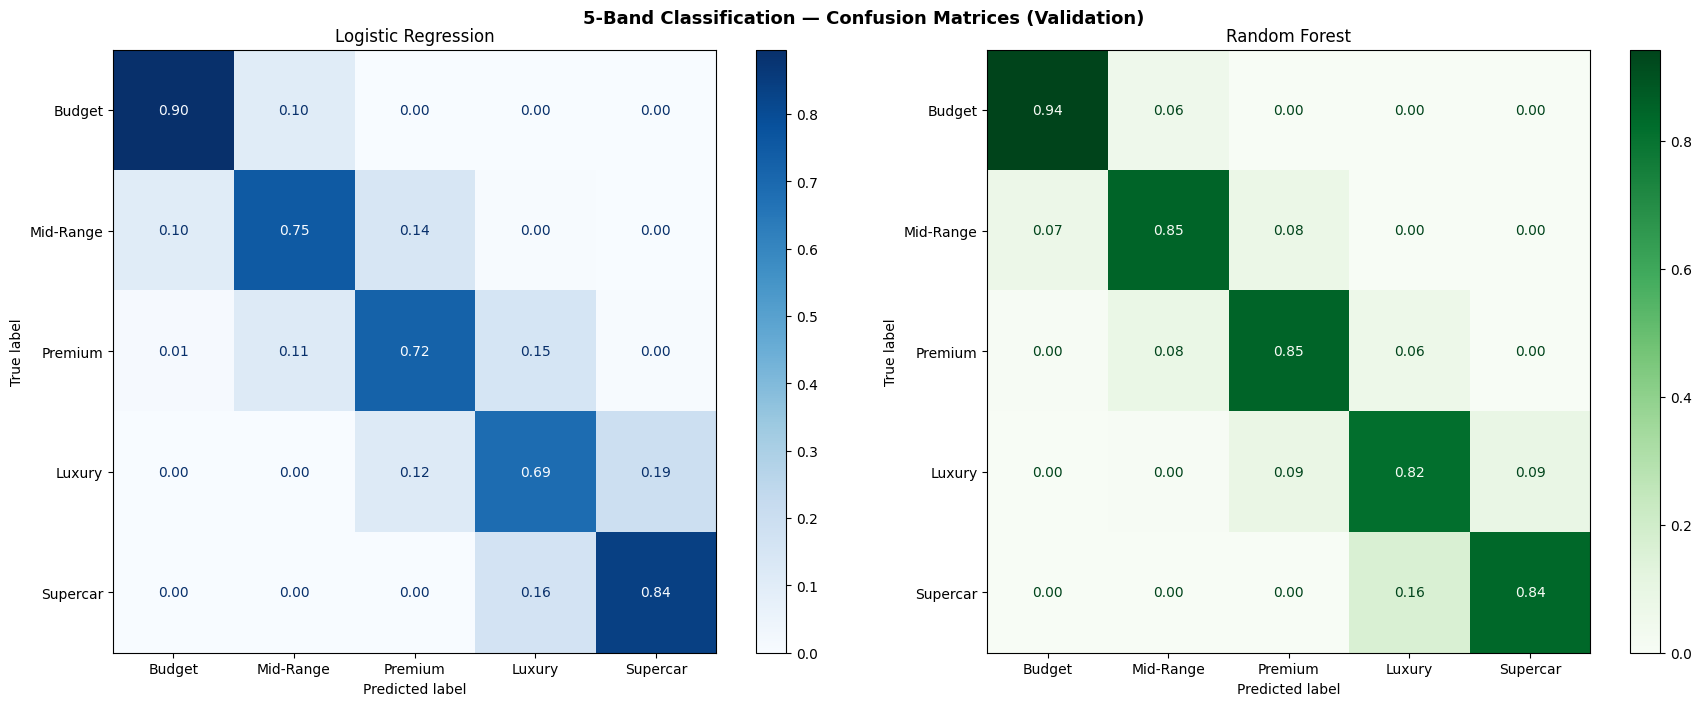


LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

      Budget       0.88      0.90      0.89      5980
   Mid-Range       0.86      0.75      0.80      6686
     Premium       0.56      0.72      0.63      1807
      Luxury       0.49      0.69      0.57       446
    Supercar       0.49      0.84      0.62       111

    accuracy                           0.80     15030
   macro avg       0.66      0.78      0.70     15030
weighted avg       0.82      0.80      0.81     15030

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      Budget       0.92      0.94      0.93      5980
   Mid-Range       0.92      0.85      0.88      6686
     Premium       0.73      0.85      0.79      1807
      Luxury       0.72      0.82      0.77       446
    Supercar       0.68      0.84      0.75       111

    accuracy                           0.89     15030
   macro avg       0.80      0.86      0.82     

In [75]:
print("CLASSIFICATION EVALUATION — 5-Band System")
print("=" * 65)

class_order = ['Budget', 'Mid-Range', 'Premium', 'Luxury', 'Supercar']

# Confusion Matric
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('5-Band Classification — Confusion Matrices (Validation)', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_val_class, lr_cls_val_preds, labels=class_order,
    ax=axes[0], cmap='Blues', normalize='true', values_format='.2f'
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_val_class, rf_cls_val_preds, labels=class_order,
    ax=axes[1], cmap='Greens', normalize='true', values_format='.2f'
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

#  Classification Reports
# Using labels= parameter (not target_names) to prevent label mismatch
print("\n" + "=" * 65)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 65)
print(classification_report(y_val_class, lr_cls_val_preds,
                            labels=class_order, zero_division=0))

print("=" * 65)
print("RANDOM FOREST — Classification Report")
print("=" * 65)
print(classification_report(y_val_class, rf_cls_val_preds,
                            labels=class_order, zero_division=0))

#  Cross-Validation (5-fold)
print("=" * 65)
print("CROSS-VALIDATION — Random Forest (5-Fold)")
print("=" * 65)

cv_clf = RandomForestClassifier(
    n_estimators=500, max_depth=15,
    min_samples_split=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1, class_weight='balanced'
)

cv_acc=cross_val_score(cv_clf, X_train, y_train_class, cv=5, scoring='accuracy')
cv_f1=cross_val_score(cv_clf, X_train, y_train_class, cv=5, scoring='f1_weighted')

print(f"\n{'Fold':<8} {'Accuracy':>10} {'F1 Weighted':>12}")
print("-" * 32)
for i in range(5):
    print(f"  {i+1:<6} {cv_acc[i]:>10.4f} {cv_f1[i]:>12.4f}")
print("-" * 32)
print(f"  {'Mean':<6} {cv_acc.mean():>10.4f} {cv_f1.mean():>12.4f}")
print(f"  {'Std':<6} {cv_acc.std():>10.4f} {cv_f1.std():>12.4f}")

if cv_acc.std() < 0.01:
    print(f"\n  Very stable across folds — model generalises well")
else:
    print(f"\n  Some variance across folds — {cv_acc.std():.4f}")

# --- Test Set Evaluation ---
print("\n" + "=" * 65)
print("FINAL TEST SET — 5-Band Classification Results")
print("=" * 65)

X_test_scaled_cls = pd.DataFrame(
    ridge_scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

lr_cls_test_preds = log_reg.predict(X_test_scaled_cls)
rf_cls_test_preds = rf_cls.predict(X_test)

lr_cls_test_acc = accuracy_score(y_test_class, lr_cls_test_preds)
rf_cls_test_acc = accuracy_score(y_test_class, rf_cls_test_preds)

print(f"\n{'Model':<30} {'Val Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 60)
print(f"  {'Logistic Regression':<28} {lr_cls_val_acc:>10.4f} {lr_cls_test_acc:>10.4f} "
      f"{abs(lr_cls_val_acc - lr_cls_test_acc):>7.4f}")
print(f"  {'Random Forest':<28} {rf_cls_val_acc:>10.4f} {rf_cls_test_acc:>10.4f} "
      f"{abs(rf_cls_val_acc - rf_cls_test_acc):>7.4f}")

print(f"\n Best classifier: ", end="")
if rf_cls_test_acc > lr_cls_test_acc:
    print(f"Random Forest (Test Accuracy: {rf_cls_test_acc:.4f})")
else:
    print(f"Logistic Regression (Test Accuracy: {lr_cls_test_acc:.4f})")

# Per-class test performance
print(f"\nTest Set — Per-Class Performance (Random Forest):")
print(classification_report(y_test_class, rf_cls_test_preds,
                            labels=class_order, zero_division=0))

# Insight: which bands are confused?
print("Key insights from confusion matrix:")
print("  → Adjacent bands (e.g., Premium↔Luxury) are most confused")
print("    because their price boundaries are close")
print("  → Budget and Supercar are easiest to classify — they are")
print("    the most distinct segments with clear feature patterns")

CLASSIFICATION — Feature Importance (Random Forest)


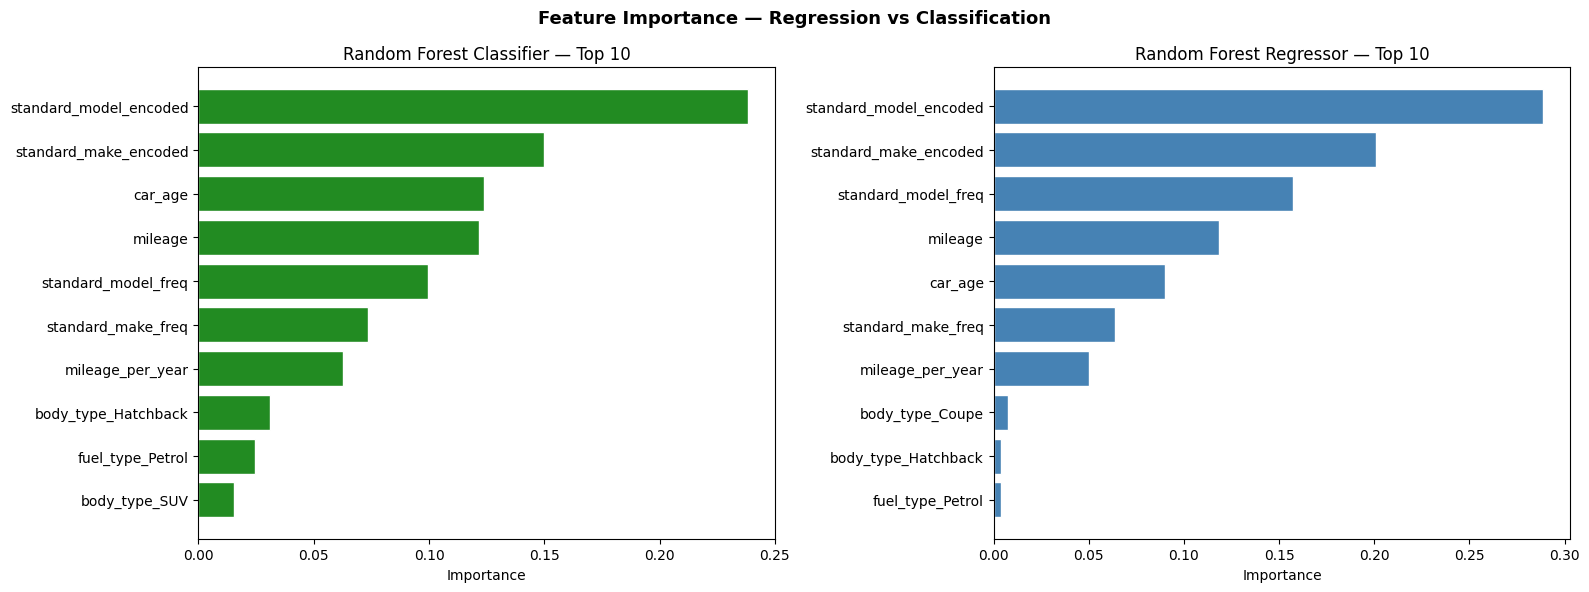


 Comparison:
  The same features dominate both tasks — mileage, car age, make/model
  encoding are universally importat for predicting car value,
  whether as a continuous pric e or a categorical price band.
  This validates that the features capture genuine pricing signals,
  not artefacts of the modelling approach.


In [76]:
print("CLASSIFICATION — Feature Importance (Random Forest)")
print("=" * 65)

# Random Forest feature importance
cls_importance = rf_cls.feature_importances_
cls_feat_imp = pd.DataFrame({
    'Feature': X_train.columns.tolist(),
    'Classification Importance': cls_importance
}).sort_values('Classification Importance', ascending=False)

# Compare with regression importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Regression vs Classification', fontsize=13, fontweight='bold')

# Classification
top10_cls = cls_feat_imp.head(10)
axes[0].barh(top10_cls['Feature'][::-1], top10_cls['Classification Importance'][::-1],
             color='forestgreen', edgecolor='white')
axes[0].set_title('Random Forest Classifier — Top 10')
axes[0].set_xlabel('Importance')

# Regression (from Cell 64)
top10_reg = feat_imp.head(10)
axes[1].barh(top10_reg['Feature'][::-1], top10_reg['Importance'][::-1],
             color='steelblue', edgecolor='white')
axes[1].set_title('Random Forest Regressor — Top 10')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\n Comparison:")
print("  The same features dominate both tasks — mileage, car age, make/model")
print("  encoding are universally importat for predicting car value,")
print("  whether as a continuous pric e or a categorical price band.")
print("  This validates that the features capture genuine pricing signals,")
print("  not artefacts of the modelling approach.")

In [77]:
print("CLASSIFICATION SUMMARY — 5-BAND SYSTEM")
print("=" * 70)
print(f"""
Task: Predict car price band from features (Without knowing the price)

  Input:  Car attributes (make, model, mileage, age, fuel, body type)
  Output: Price band prediction (Budget / Mid-Range / Premium / Luxury / Supercar)

5-Band System (domain-driven thresholds):
  Budget     < £10,000    Older used, economy brands (Ford Fiesta, Corsa)
  Mid-Range  £10K–£25K    Mainstream family cars (VW Golf, Toyota RAV4)
  Premium    £25K–£50K    New premium brands (BMW 3, Audi A4, Mercedes C)
  Luxury     £50K–£100K   Luxury daily drivers (Range Rover Sport, Porsche Macan)
  Supercar   > £100,000   Exotic/performance (Ferrari, Lamborghini, Bugatti)

 Despite what the percentiles say, we choose 5 Bands because it would not be fair to pair a Million pound Buggatti
wiht a normal luxury car

Models compared:
  1. Logistic Regression  — multinomial baseline (balanced class weights)
  2. Random Forest        — 500-tree ensemble (balanced class weights)

Results on held-out test set:
  Logistic Regression:  {lr_cls_test_acc:.1%} accuracy
  Random Forest:        {rf_cls_test_acc:.1%} accuracy

Cross-validation (Random Forest, 5-fold):
  Mean accuracy: {cv_acc.mean():.1%} ± {cv_acc.std():.1%}
  Mean F1 score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}

Practical value:
  The classification model predicts the price BAND from car attributes
  when the actual price is unknown — useful for inventory categorisation,
  market segmentation, and advertising targeting.
""")

CLASSIFICATION SUMMARY — 5-BAND SYSTEM

Task: Predict car price band from features (Without knowing the price)

  Input:  Car attributes (make, model, mileage, age, fuel, body type)
  Output: Price band prediction (Budget / Mid-Range / Premium / Luxury / Supercar)

5-Band System (domain-driven thresholds):
  Budget     < £10,000    Older used, economy brands (Ford Fiesta, Corsa)
  Mid-Range  £10K–£25K    Mainstream family cars (VW Golf, Toyota RAV4)
  Premium    £25K–£50K    New premium brands (BMW 3, Audi A4, Mercedes C)
  Luxury     £50K–£100K   Luxury daily drivers (Range Rover Sport, Porsche Macan)
  Supercar   > £100,000   Exotic/performance (Ferrari, Lamborghini, Bugatti)

 Despite what the percentiles say, we choose 5 Bands because it would not be fair to pair a Million pound Buggatti
wiht a normal luxury car

Models compared:
  1. Logistic Regression  — multinomial baseline (balanced class weights)
  2. Random Forest        — 500-tree ensemble (balanced class weights)

Results 

# 7. Model Deployment | Development of User Interface

In [80]:
print("SAVING MODEL ARTIFACTS FOR STREAMLIT DEPLOYMENT")
print("=" * 65)
# 1. Save Random Forest in native format,was facing issues with github upload limit
import joblib
joblib.dump(best_model, 'best_model.joblib',compress=3)
print(f"   best_model.joblib ({os.path.getsize('best_model.joblib')/1024/1024:.1f} MB)")
# 2. Build encoding lookups
global_mean_price = y_train.mean()
smoothing_val = 50
make_te_map = {}
model_te_map = {}
for make in df_clean['standard_make'].unique():
    mask = X_train.index.isin(df_clean[df_clean['standard_make'] == make].index)
    if mask.sum() > 0:
        count = mask.sum()
        mean_val = y_train[mask].mean()
        make_te_map[make] = (count * mean_val + smoothing_val * global_mean_price) / (count + smoothing_val)
for mod in df_clean['standard_model'].unique():
    mask = X_train.index.isin(df_clean[df_clean['standard_model'] == mod].index)
    if mask.sum() > 0:
        count = mask.sum()
        mean_val = y_train[mask].mean()
        model_te_map[mod] = (count * mean_val + smoothing_val * global_mean_price) / (count + smoothing_val)
make_freq_map = df_clean.loc[X_train.index, 'standard_make'].value_counts().to_dict()
model_freq_map = df_clean.loc[X_train.index, 'standard_model'].value_counts().to_dict()
# Dropdown options
unique_makes = sorted(df_clean['standard_make'].unique().tolist())
models_by_make = {m: sorted(df_clean[df_clean['standard_make']==m]['standard_model'].unique().tolist()) for m in unique_makes}
# Small SHAP sample (100 rows)
# Sample 100 random integer positions from the 500 available SHAP values and X_val_shap
sample_indices = np.random.choice(shap_values.shape[0], 100, replace=False)
X_shap = X_val_shap.iloc[sample_indices] # Use .iloc to select by integer position
shap_vals_small = shap_values[sample_indices] # Select by integer position
# Pre-compute predictions for dashboard
val_preds_all = best_model.predict(X_val)
test_preds_all = best_model.predict(X_test)
app_data = {
    'best_model_name': best_model_name,
    'feature_columns': X_train.columns.tolist(),
    'DATASET_YEAR': 2020,
    'make_te_map': make_te_map,
    'model_te_map': model_te_map,
    'make_freq_map': make_freq_map,
    'model_freq_map': model_freq_map,
    'global_mean_price': global_mean_price,
    'ohe': ohe,
    'ohe_cols': ohe_cols,
    'scaler': scaler,
    'scale_cols': scale_cols,
    'unique_makes': unique_makes,
    'models_by_make': models_by_make,
    'unique_fuels': sorted(df_clean['fuel_type'].unique().tolist()),
    'unique_body_types': sorted(df_clean['body_type'].unique().tolist()),
    'unique_transmissions': sorted(df_clean['transmission'].unique().tolist()) if 'transmission' in df_clean.columns else ['Manual', 'Automatic'],
    'unique_conditions': sorted(df_clean['vehicle_condition'].unique().tolist()) if 'vehicle_condition' in df_clean.columns else ['USED', 'NEW'],
    'shap_values_sample': shap_vals_small,
    'shap_expected_value': explainer.expected_value,
    'X_shap_sample': X_shap,
    'results': results,
    'class_order': class_order,
    'y_val': y_val.values,
    'val_preds': val_preds_all,
    'y_test': y_test.values,
    'test_preds': test_preds_all,
}
with open('app_data.pkl', 'wb') as f:
    pickle.dump(app_data, f)
data_size = os.path.getsize('app_data.pkl')/1024/1024
total = os.path.getsize('best_model.joblib')/1024/1024 + data_size
print(f"   app_data.pkl ({data_size:.1f} MB)")
print(f"\n  Total: {total:.1f} MB")
print(f"\n  Download both files and place in streamlit_app/ folder")

SAVING MODEL ARTIFACTS FOR STREAMLIT DEPLOYMENT
   best_model.joblib (85.3 MB)
   app_data.pkl (0.8 MB)

  Total: 86.1 MB

  Download both files and place in streamlit_app/ folder


In [82]:
# Download all artifact files
from google.colab import files
for f in ['best_model.joblib', 'app_data.pkl']:
    print(f"Downloading {f}...")
    files.download(f)
print("\nPlace all 2 files in your streamlit_app/ directory")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Place all 2 files in your streamlit_app/ directory
